# 02. 目的変数の設定と説明変数の設計 — 2026-03-08

## リクルート飲食店来客数予測コンペティション

**目的**: 予測モデルに使う目的変数（何を予測するか）と説明変数（予測に使う情報）を整理・設計する。

### 本ノートブックの構成
1. データ読み込みと準備
2. 目的変数の設定（来客数 → log1p変換）
3. 説明変数の分類と設計方針
4. 時間特徴量の作成と効果検証
5. 店舗統計量の作成と効果検証
6. Rolling統計量・ラグ特徴量の作成と効果検証
7. 特徴量の段階的効果比較
8. 特徴量重要度の分析
9. 相関分析
10. 学習データ期間の検証
11. NaN処理戦略の検証
12. Rolling手法の比較検証
13. まとめ

---
## 1. データ読み込みと準備

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
plt.rcParams['figure.facecolor'] = 'white'
pd.set_option('display.max_columns', 50)

SEED = 42
np.random.seed(SEED)
INPUT_DIR = Path('../../input')
INTERMEDIATE_DIR = Path('./intermediate')

def rmsle(y_true, y_pred):
    """コンペ評価指標: RMSLE (Root Mean Squared Logarithmic Error)"""
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

# 全テーブルの読み込み
air_visit = pd.read_csv(INPUT_DIR / 'air_visit_data.csv', parse_dates=['visit_date'])
air_store = pd.read_csv(INPUT_DIR / 'air_store_info.csv')
air_reserve = pd.read_csv(INPUT_DIR / 'air_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
hpg_reserve = pd.read_csv(INPUT_DIR / 'hpg_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
store_relation = pd.read_csv(INPUT_DIR / 'store_id_relation.csv')
date_info = pd.read_csv(INPUT_DIR / 'date_info.csv', parse_dates=['calendar_date'])

# 01 EDAの中間データを読み込み（ジャンル別分析結果）
eda_pkl_path = INTERMEDIATE_DIR / '01_eda_results.pkl'
if eda_pkl_path.exists():
    with open(eda_pkl_path, 'rb') as f:
        eda_results = pickle.load(f)
    print('✓ 01_eda_results.pkl 読み込み完了')
    print(f'  キー: {list(eda_results.keys())}')
    # 主要データを展開
    eda_genre_stats = eda_results['genre_stats']
    eda_genre_dow = eda_results['genre_dow']
    eda_genre_holiday = eda_results['genre_holiday']
    eda_genre_reserve_coverage = eda_results['genre_reserve_coverage']
    eda_genre_closure_pattern = eda_results['genre_closure_pattern']
    eda_genre_feature_effectiveness = eda_results['genre_feature_effectiveness']
    eda_genre_recommendations = eda_results['genre_recommendations']
    eda_closure_dow_df = eda_results['closure_dow_df']
    eda_val_folds = eda_results['val_folds']
    
    # val_foldsの内容を確認
    print(f'\n=== 時系列CV設定（01 EDAで設計） ===')
    print(f'  フォールド数: {len(eda_val_folds)}')
    for i, fold in enumerate(eda_val_folds):
        print(f'  Fold {i+1}: val_start={fold["val_start"]}, val_end={fold["val_end"]}')
else:
    print('⚠ 01_eda_results.pkl が見つかりません。01ノートブックを先に実行してください。')
    eda_results = None

print(f'\nデータ読み込み完了')
print(f'  来客データ: {air_visit.shape[0]:,}件 / {air_visit["air_store_id"].nunique()}店舗')
print(f'  期間: {air_visit["visit_date"].min().date()} ～ {air_visit["visit_date"].max().date()}')

✓ 01_eda_results.pkl 読み込み完了
  キー: ['genre_stats', 'genre_dow', 'genre_holiday', 'genre_reserve_coverage', 'genre_closure_pattern', 'genre_feature_effectiveness', 'genre_recommendations', 'store_lifecycle', 'closure_dow_df', 'air_res_daily', 'res_vs_actual', 'ratio_with_genre', 'val_folds']

=== 時系列CV設定（01 EDAで設計） ===
  フォールド数: 5
  Fold 1: val_start=2016-04-23, val_end=2016-05-31
  Fold 2: val_start=2016-07-16, val_end=2016-08-23
  Fold 3: val_start=2016-10-15, val_end=2016-11-22
  Fold 4: val_start=2016-12-16, val_end=2017-01-23
  Fold 5: val_start=2017-03-15, val_end=2017-04-22

データ読み込み完了
  来客データ: 252,108件 / 829店舗
  期間: 2016-01-01 ～ 2017-04-22


---
## 2. 目的変数の設定

### 目的変数: `visitors`（日別来客数）

このコンペでは、各店舗の日別来客数を予測する。評価指標は **RMSLE（Root Mean Squared Logarithmic Error）** である。

### なぜ log1p 変換を使うか

| 理由 | 説明 |
|------|------|
| 評価指標との整合性 | RMSLEは内部的に `log1p(y)` を使って計算される。目的変数をlog1p変換してRMSEで学習すれば、直接RMSLEを最適化できる |
| 分布の正規化 | 来客数は右に歪んだ分布。log1p変換で正規分布に近づく |
| 外れ値の影響緩和 | 来客数が極端に多い日の影響を軽減できる |
| スケールの統一 | 来客数が10人の店舗と200人の店舗を同じスケールで扱える |

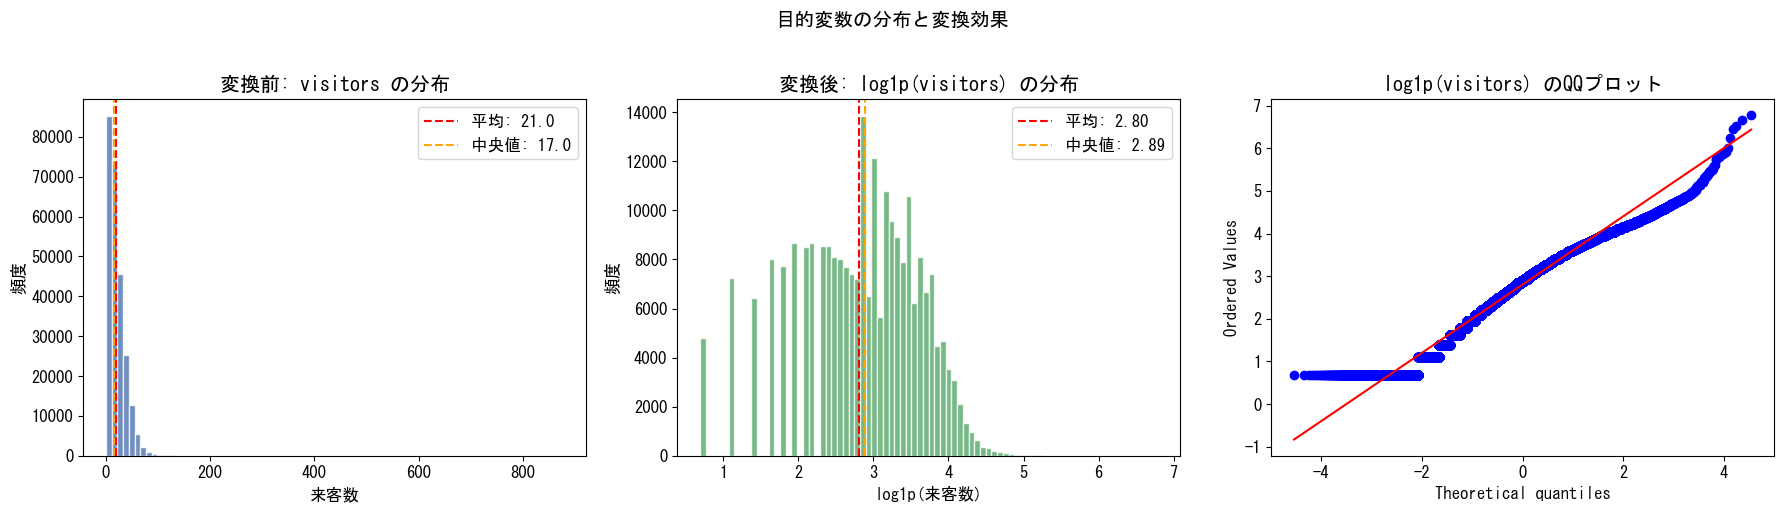

=== 目的変数の統計量 ===
変換前 — 歪度: 3.308, 尖度: 74.259
変換後 — 歪度: -0.451, 尖度: -0.176

→ log1p変換により歪度が大幅に改善され、正規分布に近づいている


In [23]:
# 目的変数の分布確認: 変換前 vs 変換後
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 変換前の分布
axes[0].hist(air_visit['visitors'], bins=80, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0].set_title('変換前: visitors の分布')
axes[0].set_xlabel('来客数')
axes[0].set_ylabel('頻度')
axes[0].axvline(air_visit['visitors'].mean(), color='red', linestyle='--', label=f'平均: {air_visit["visitors"].mean():.1f}')
axes[0].axvline(air_visit['visitors'].median(), color='orange', linestyle='--', label=f'中央値: {air_visit["visitors"].median():.1f}')
axes[0].legend()

# log1p変換後の分布
log_visitors = np.log1p(air_visit['visitors'])
axes[1].hist(log_visitors, bins=80, color='#55A868', edgecolor='white', alpha=0.8)
axes[1].set_title('変換後: log1p(visitors) の分布')
axes[1].set_xlabel('log1p(来客数)')
axes[1].set_ylabel('頻度')
axes[1].axvline(log_visitors.mean(), color='red', linestyle='--', label=f'平均: {log_visitors.mean():.2f}')
axes[1].axvline(log_visitors.median(), color='orange', linestyle='--', label=f'中央値: {log_visitors.median():.2f}')
axes[1].legend()

# QQプロット（正規性の確認）
from scipy import stats
stats.probplot(log_visitors, dist='norm', plot=axes[2])
axes[2].set_title('log1p(visitors) のQQプロット')

plt.suptitle('目的変数の分布と変換効果', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 統計量の比較
print('=== 目的変数の統計量 ===')
print(f'変換前 — 歪度: {air_visit["visitors"].skew():.3f}, 尖度: {air_visit["visitors"].kurtosis():.3f}')
print(f'変換後 — 歪度: {log_visitors.skew():.3f}, 尖度: {log_visitors.kurtosis():.3f}')
print(f'\n→ log1p変換により歪度が大幅に改善され、正規分布に近づいている')

---
## 3. 説明変数の分類と設計方針

EDA（01）の分析結果と上位解法の知見をもとに、説明変数を以下の5カテゴリに分類する。

| カテゴリ | 特徴量例 | 重要度 | 根拠 |
|---------|---------|--------|------|
| 時間特徴量 | 曜日、月、祝日フラグ | ★★★ | EDAで強い曜日パターンを確認済み |
| 店舗統計量 | 店舗平均、店舗×曜日平均 | ★★★★ | 店舗ごとの来客規模が大きく異なる |
| Rolling統計量 | 過去N日の平均・標準偏差 | ★★★★★ | 上位解法で最重要とされる |
| ラグ特徴量 | N日前の来客数 | ★★★ | 直近の傾向を反映 |
| 予約情報 | 予約人数合計 | ★★ | カバー率は低いが、ある場合は有用 |

### 設計上の注意点
- **データリーク防止**: Rolling/ラグ特徴量は必ず `.shift(1)` してから計算（当日のデータを使わない）
- **テストデータへの適用**: 統計量は学習データのみから算出する
- **欠損値処理**: 予約データが無い日は0として扱う

### 検証方法
各カテゴリの特徴量を**段階的に追加**し、RMSLEの改善幅を確認する。これにより、どの特徴量カテゴリが最も効果的かを定量的に示す。

In [24]:
# ベースデータの構築
# 店舗情報と日付情報を結合
df = air_visit.merge(air_store, on='air_store_id', how='left')
df = df.merge(
    date_info.rename(columns={'calendar_date': 'visit_date'}),
    on='visit_date', how='left'
)

# 時系列バリデーション用の分割
# テスト期間 (2017/4/23～5/31) の直前を検証期間とする
VALID_START = '2017-03-12'
train = df[df['visit_date'] < VALID_START].copy()
valid = df[df['visit_date'] >= VALID_START].copy()

print('=== データ分割 ===')
print(f'学習データ: {train.shape[0]:,}件 ({train["visit_date"].min().date()} ～ {train["visit_date"].max().date()})')
print(f'検証データ: {valid.shape[0]:,}件 ({valid["visit_date"].min().date()} ～ {valid["visit_date"].max().date()})')
print(f'\n検証期間は{(valid["visit_date"].max() - valid["visit_date"].min()).days + 1}日間')

=== データ分割 ===
学習データ: 222,073件 (2016-01-01 ～ 2017-03-11)
検証データ: 30,035件 (2017-03-12 ～ 2017-04-22)

検証期間は42日間


---
## 4. 時間特徴量の作成と効果検証

EDAで確認した曜日・月パターンを特徴量化する。

| 特徴量 | 説明 | EDAでの根拠 |
|--------|------|-------------|
| `dow` | 曜日 (0=月～6=日) | 金曜・土曜がピーク、日曜・月曜が低い |
| `month` | 月 | 季節変動あり（12月が高い等） |
| `day` | 日 | 月内の位置（給料日効果の可能性） |
| `week` | ISO週番号 | 年間の位置 |
| `is_weekend` | 週末フラグ | 土日で来客数が異なる |
| `is_holiday` | 祝日フラグ | 祝日は来客数に大きな影響 |

In [25]:
def add_time_features(df):
    """時間特徴量を追加する関数"""
    df = df.copy()
    df['month'] = df['visit_date'].dt.month
    df['day'] = df['visit_date'].dt.day
    df['dow'] = df['visit_date'].dt.dayofweek
    df['week'] = df['visit_date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['is_holiday'] = df['holiday_flg'].fillna(0).astype(int)
    return df

train_t = add_time_features(train)
valid_t = add_time_features(valid)

# 時間特徴量のみでLightGBMを学習し、ベースラインを確立
time_features = ['month', 'day', 'dow', 'week', 'is_weekend', 'is_holiday']

lgb_data = lgb.Dataset(train_t[time_features], label=np.log1p(train_t['visitors']))
model_time = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'verbose': -1, 'random_state': SEED},
    lgb_data, num_boost_round=300
)

pred = np.expm1(model_time.predict(valid_t[time_features]))
score_time = rmsle(valid_t['visitors'], pred)
print(f'【ステップ1】時間特徴量のみ → RMSLE: {score_time:.5f}')
print(f'  使用特徴量数: {len(time_features)}個')
print(f'  使用特徴量: {time_features}')

【ステップ1】時間特徴量のみ → RMSLE: 0.81948
  使用特徴量数: 6個
  使用特徴量: ['month', 'day', 'dow', 'week', 'is_weekend', 'is_holiday']


---
## 5. 店舗統計量の作成と効果検証

店舗ごとの来客数は大きくばらつく（EDAで確認済み）。過去の統計量を使って店舗ごとの「基準レベル」を伝える。

| 特徴量 | 説明 |
|--------|------|
| `store_mean / median / std / min / max` | 店舗別の来客数統計量 |
| `store_count` | 店舗のレコード数（データの豊富さ） |
| `store_dow_mean / median` | 店舗×曜日の平均・中央値（曜日ごとの傾向を店舗別に） |
| `genre_mean / median` | ジャンル別の来客数統計量 |
| `genre_encoded / area_encoded` | ジャンル・エリアのエンコーディング |
| `latitude / longitude` | 店舗の位置情報 |

In [26]:
# 店舗別統計量（学習データのみから算出 — リーク防止）
store_stats = train[train['visit_date'] < VALID_START].groupby('air_store_id')['visitors'].agg(
    ['mean', 'median', 'std', 'min', 'max', 'count']
).reset_index()
store_stats.columns = ['air_store_id', 'store_mean', 'store_median', 'store_std',
                        'store_min', 'store_max', 'store_count']

# 店舗×曜日の統計量
train_dow = train.copy()
train_dow['dow'] = train_dow['visit_date'].dt.dayofweek
store_dow = train_dow.groupby(['air_store_id', 'dow'])['visitors'].agg(['mean', 'median']).reset_index()
store_dow.columns = ['air_store_id', 'dow', 'store_dow_mean', 'store_dow_median']

# ジャンル別の統計量
genre_stats = train.groupby('air_genre_name')['visitors'].agg(['mean', 'median']).reset_index()
genre_stats.columns = ['air_genre_name', 'genre_mean', 'genre_median']

# カテゴリ変数のエンコーディング
for d in [train_t, valid_t]:
    d['genre_encoded'] = d['air_genre_name'].factorize()[0]
    d['area_encoded'] = d['air_area_name'].factorize()[0]

# 学習・検証データに結合
train_ts = train_t.merge(store_stats, on='air_store_id', how='left')
train_ts = train_ts.merge(store_dow, on=['air_store_id', 'dow'], how='left')
train_ts = train_ts.merge(genre_stats, on='air_genre_name', how='left')

valid_ts = valid_t.merge(store_stats, on='air_store_id', how='left')
valid_ts = valid_ts.merge(store_dow, on=['air_store_id', 'dow'], how='left')
valid_ts = valid_ts.merge(genre_stats, on='air_genre_name', how='left')

# 時間 + 店舗統計量で予測
store_features = time_features + [
    'genre_encoded', 'area_encoded', 'latitude', 'longitude',
    'store_mean', 'store_median', 'store_std', 'store_min', 'store_max', 'store_count',
    'store_dow_mean', 'store_dow_median', 'genre_mean', 'genre_median'
]

lgb_data2 = lgb.Dataset(train_ts[store_features], label=np.log1p(train_ts['visitors']))
model_store = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'verbose': -1, 'random_state': SEED, 'num_leaves': 63},
    lgb_data2, num_boost_round=500
)

pred2 = np.expm1(model_store.predict(valid_ts[store_features]))
score_store = rmsle(valid_ts['visitors'], pred2)
print(f'【ステップ2】時間 + 店舗統計量 → RMSLE: {score_store:.5f}')
print(f'  使用特徴量数: {len(store_features)}個')
print(f'  ステップ1からの改善幅: {score_time - score_store:.5f}')
print(f'\n→ 店舗統計量の追加で大幅にスコアが改善。店舗ごとの来客規模を伝えることが非常に重要。')

【ステップ2】時間 + 店舗統計量 → RMSLE: 0.56187
  使用特徴量数: 20個
  ステップ1からの改善幅: 0.25761

→ 店舗統計量の追加で大幅にスコアが改善。店舗ごとの来客規模を伝えることが非常に重要。


---
## 5b. ジャンル交互作用特徴量の作成と効果検証

01のEDA分析で、ジャンルにより以下の特性が大きく異なることが判明した：
- **曜日効果**: 居酒屋は金曜ピークが突出、カフェは曜日差が小さい
- **祝日効果**: ジャンルにより祝日の影響が正反対（増える/減る）
- **予約カバー率**: ジャンルで予約情報の有用性が異なる
- **定休日パターン**: ジャンル別に定休日の曜日傾向が異なる

→ これらを**ジャンル交互作用特徴量**として追加し、ジャンル固有のパターンをモデルに伝える。

In [27]:
# ============================================================
# ジャンル交互作用特徴量の作成
# ============================================================
# 01 EDAの分析結果（eda_results）を活用して特徴量を構築

# --- 1. genre_dow_mean: ジャンル×曜日の平均来客数 ---
genre_dow_stacked = eda_genre_dow.copy()
if not all(isinstance(c, (int, np.integer)) for c in genre_dow_stacked.columns):
    genre_dow_stacked.columns = range(len(genre_dow_stacked.columns))
genre_dow_lookup = genre_dow_stacked.stack().reset_index()
genre_dow_lookup.columns = ['air_genre_name', 'dow', 'genre_dow_mean']
genre_dow_lookup['dow'] = genre_dow_lookup['dow'].astype(int)

# --- 2. genre_holiday_ratio: ジャンル別祝日効果比率 ---
genre_holiday_lookup = eda_genre_holiday[['ratio']].reset_index()
genre_holiday_lookup.columns = ['air_genre_name', 'genre_holiday_ratio']

# --- 3. genre_reserve_coverage: ジャンル別予約カバー率 ---
genre_reserve_lookup = eda_genre_reserve_coverage[['reserve_coverage_mean']].reset_index()
genre_reserve_lookup.columns = ['air_genre_name', 'genre_reserve_coverage']

# --- 4. genre_closure_days: ジャンル別平均定休日数/週 ---
genre_closure_lookup = pd.DataFrame([
    {'air_genre_name': genre, 'genre_closure_days': info['avg_closure_days_per_week']}
    for genre, info in eda_genre_closure_pattern.items()
])

# --- 5. store_popularity_in_genre: ジャンル内相対人気度 ---

# train_ts, valid_ts に結合
for d in [train_ts, valid_ts]:
    if 'dow' not in d.columns:
        d['dow'] = d['visit_date'].dt.dayofweek
    d['dow'] = d['dow'].astype(int)
    
    d_merged = d.merge(genre_dow_lookup, on=['air_genre_name', 'dow'], how='left')
    d['genre_dow_mean'] = d_merged['genre_dow_mean'].values
    
    d_merged = d.merge(genre_holiday_lookup, on='air_genre_name', how='left')
    d['genre_holiday_ratio'] = d_merged['genre_holiday_ratio'].values
    
    d_merged = d.merge(genre_reserve_lookup, on='air_genre_name', how='left')
    d['genre_reserve_coverage'] = d_merged['genre_reserve_coverage'].values
    
    d_merged = d.merge(genre_closure_lookup, on='air_genre_name', how='left')
    d['genre_closure_days'] = d_merged['genre_closure_days'].values
    
    d['store_popularity_in_genre'] = d['store_mean'] / d['genre_mean']

# ジャンル交互作用特徴量のリスト
genre_interaction_cols = [
    'genre_dow_mean', 'genre_holiday_ratio', 'genre_reserve_coverage',
    'genre_closure_days', 'store_popularity_in_genre',
]

# --- ステップ2b: 店舗統計量 + ジャンル交互作用で検証（単一分割） ---
genre_int_features = store_features + genre_interaction_cols
lgb_data2b = lgb.Dataset(train_ts[genre_int_features], label=np.log1p(train_ts['visitors']))
model_genre_int = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'verbose': -1, 'random_state': SEED, 'num_leaves': 63},
    lgb_data2b, num_boost_round=500
)

pred2b = np.expm1(model_genre_int.predict(valid_ts[genre_int_features]))
score_genre_int = rmsle(valid_ts['visitors'], pred2b)

print(f'=== ジャンル交互作用特徴量の効果（単一分割） ===')
print(f'【ステップ2】 店舗統計量のみ          → RMSLE: {score_store:.5f}')
print(f'【ステップ2b】+ ジャンル交互作用     → RMSLE: {score_genre_int:.5f}')
print(f'  改善幅: {score_store - score_genre_int:.5f}')
print(f'  追加特徴量数: {len(genre_interaction_cols)}個')
print(f'  ※ 時系列CVでの検証はセクション7（段階的効果比較）で実施')

print(f'\n=== 追加した特徴量 ===')
for col in genre_interaction_cols:
    train_vals = train_ts[col].dropna()
    print(f'  {col}: mean={train_vals.mean():.3f}, std={train_vals.std():.3f}, '
          f'NaN率={train_ts[col].isna().mean():.1%}')

print(f'\n→ 01 EDAのジャンル別分析結果を特徴量化。')
print(f'  ジャンル固有の曜日パターン・祝日反応・予約信頼度をモデルに直接伝達。')

=== ジャンル交互作用特徴量の効果（単一分割） ===
【ステップ2】 店舗統計量のみ          → RMSLE: 0.56187
【ステップ2b】+ ジャンル交互作用     → RMSLE: 0.56272
  改善幅: -0.00085
  追加特徴量数: 5個
  ※ 時系列CVでの検証はセクション7（段階的効果比較）で実施

=== 追加した特徴量 ===
  genre_dow_mean: mean=20.953, std=4.911, NaN率=19.0%
  genre_holiday_ratio: mean=1.143, std=0.076, NaN率=0.0%
  genre_reserve_coverage: mean=0.584, std=0.216, NaN率=0.0%
  genre_closure_days: mean=0.699, std=0.173, NaN率=0.0%
  store_popularity_in_genre: mean=1.000, std=0.486, NaN率=0.0%

→ 01 EDAのジャンル別分析結果を特徴量化。
  ジャンル固有の曜日パターン・祝日反応・予約信頼度をモデルに直接伝達。


---
## 6. Rolling統計量・ラグ特徴量の作成と効果検証

**上位解法で最重要とされる特徴量カテゴリ。**

### 3層構造で設計

Rolling統計量は単純なカレンダー日ベースではなく、**休業日を考慮した3層構造**で設計する。

#### 層1: 営業日ベースのRolling統計量
- `rolling()` の計算時に、非営業日（NaN）を除外して「直近の営業日における来客傾向」を算出
- `visitors` が NaN の日 = 非営業日（定休日・臨時休業等）、0以上 = 営業日として扱う
- 休業日のNaN/0が窓に混入してRolling平均が下方バイアスされる問題を回避

#### 層2: 休業パターン特徴量（新規）
- `open_ratio_N`: 直近N日間の営業率（何割の日が営業していたか）
- `closed_streak`: 直近の連続休業日数
- `days_since_long_closure`: 3日以上の連続休業からの経過日数
- 休業パターン自体が来客数に影響する（長期休業後のリバウンド等）

#### 層3: 祝日前後の影響特徴量（新規）
- `is_after_holiday_N`: N日前が祝日だったかのフラグ（祝日明けの反動）
- `holiday_count_N`: 直近N日間の祝日日数
- `is_near_special_period`: 特別期間（正月・GW・お盆・年末）の前後フラグ

### ウィンドウサイズの選定根拠

| ウィンドウ | 意味 | 捉えるパターン |
|-----------|------|---------------|
| 7日 | 1週間 | 直近の短期変動 |
| 14日 | 2週間 | 安定した短期傾向 |
| 21日 | 3週間 | 月単位の傾向 |
| 35日 | 5週間 | 中期トレンド |
| 63日 | 約2ヶ月 | 季節傾向 |

### ラグ特徴量
- `lag_1`: 前日の来客数（最新の情報）
- `lag_7`: 1週間前の同曜日（曜日パターンの反映）
- `lag_14, 21, 28, 35`: 2〜5週前の同曜日

In [28]:
# ============================================================
# 層1: 営業日ベースのRolling統計量・ラグ特徴量
# ============================================================
# 全店舗×全日付のグリッドを構築（欠損日も含める）
# left joinにより非営業日のvisitorsはNaNとなる
# → rolling()はNaNを自動的にスキップするため、営業日ベースの統計量になる
all_stores = df['air_store_id'].unique()
train_data = air_visit[air_visit['visit_date'] < '2017-04-23'][['air_store_id', 'visit_date', 'visitors']]
min_date = train_data['visit_date'].min()
max_date = df['visit_date'].max()
all_dates = pd.date_range(min_date, max_date, freq='D')

grid = pd.MultiIndex.from_product([all_stores, all_dates], names=['air_store_id', 'visit_date'])
grid_df = pd.DataFrame(index=grid).reset_index()
grid_df = grid_df.merge(train_data, on=['air_store_id', 'visit_date'], how='left')

# 祝日情報を結合（層3で使用）
grid_df = grid_df.merge(
    date_info[['calendar_date', 'holiday_flg']].rename(columns={'calendar_date': 'visit_date'}),
    on='visit_date', how='left'
)

grid_df = grid_df.sort_values(['air_store_id', 'visit_date']).reset_index(drop=True)

# 営業フラグ: visitorsがNaNでない日 = 営業日
grid_df['is_open'] = grid_df['visitors'].notna().astype(int)

# --- 層1: Rolling統計量（営業日ベース） ---
# NaNはrolling().mean()で自動的にスキップされるため、営業日のみの平均となる
windows = [7, 14, 21, 35, 63]
for w in windows:
    grouped = grid_df.groupby('air_store_id')['visitors']
    grid_df[f'rolling_mean_{w}'] = grouped.transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    grid_df[f'rolling_std_{w}'] = grouped.transform(lambda x: x.shift(1).rolling(w, min_periods=1).std())

# 指数加重移動平均（NaNを自動スキップ）
grid_df['ewm_mean'] = grid_df.groupby('air_store_id')['visitors'].transform(
    lambda x: x.shift(1).ewm(span=14, min_periods=1).mean()
)

# ラグ特徴量（営業日の値がそのまま使われる、非営業日はNaN）
for lag in [1, 7, 14, 21, 28, 35]:
    grid_df[f'lag_{lag}'] = grid_df.groupby('air_store_id')['visitors'].shift(lag)

# ============================================================
# 層2: 休業パターン特徴量
# ============================================================
# open_ratio_N: 直近N日間の営業率
for w in [7, 14, 28]:
    grid_df[f'open_ratio_{w}'] = grid_df.groupby('air_store_id')['is_open'].transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).mean()
    )

# closed_streak: 直近の連続休業日数
def calc_closed_streak(s):
    """各時点における直近の連続休業日数を計算"""
    result = np.zeros(len(s))
    streak = 0
    for i in range(len(s)):
        if i == 0:
            result[i] = 0
        elif s.iloc[i - 1] == 0:  # 前日が休業
            streak += 1
            result[i] = streak
        else:
            streak = 0
            result[i] = 0
    return pd.Series(result, index=s.index)

grid_df['closed_streak'] = grid_df.groupby('air_store_id')['is_open'].transform(calc_closed_streak)

# days_since_long_closure: 3日以上の連続休業からの経過日数
def calc_days_since_long_closure(s):
    """3日以上の連続休業が終わってからの経過日数を計算"""
    result = np.full(len(s), -1.0)  # -1 = まだ長期休業なし
    streak = 0
    days_since = -1
    for i in range(len(s)):
        if s.iloc[i] == 0:  # 休業日
            streak += 1
            if days_since >= 0:
                days_since += 1
                result[i] = days_since
        else:  # 営業日
            if streak >= 3:  # 長期休業が終わった
                days_since = 0
            elif days_since >= 0:
                days_since += 1
            streak = 0
            result[i] = days_since if days_since >= 0 else -1
    return pd.Series(result, index=s.index)

grid_df['days_since_long_closure'] = grid_df.groupby('air_store_id')['is_open'].transform(
    calc_days_since_long_closure
)
# -1（長期休業未経験）はNaNに変換
grid_df['days_since_long_closure'] = grid_df['days_since_long_closure'].replace(-1, np.nan)

# ============================================================
# 層3: 祝日前後の影響特徴量
# ============================================================
holiday_flag = grid_df['holiday_flg'].fillna(0).astype(int)

# is_after_holiday_N: N日前が祝日だったかのフラグ
for n in [1, 2, 3]:
    grid_df[f'is_after_holiday_{n}'] = grid_df.groupby('air_store_id')['holiday_flg'].transform(
        lambda x: x.fillna(0).shift(n)
    ).astype(float)

# holiday_count_N: 直近N日間の祝日日数
for w in [7, 14]:
    grid_df[f'holiday_count_{w}'] = grid_df.groupby('air_store_id')['holiday_flg'].transform(
        lambda x: x.fillna(0).shift(1).rolling(w, min_periods=1).sum()
    )

# is_near_special_period: 特別期間（正月・GW・お盆・年末）の前後フラグ
def is_special_period(dt):
    """特別期間（正月・GW・お盆・年末）の前後7日以内かを判定"""
    m, d = dt.month, dt.day
    # 正月: 12/28 ～ 1/7
    if (m == 12 and d >= 28) or (m == 1 and d <= 7):
        return 1
    # GW: 4/27 ～ 5/10
    if (m == 4 and d >= 27) or (m == 5 and d <= 10):
        return 1
    # お盆: 8/8 ～ 8/20
    if m == 8 and 8 <= d <= 20:
        return 1
    return 0

grid_df['is_near_special_period'] = grid_df['visit_date'].apply(is_special_period)

# --- 特徴量一覧の出力 ---
rolling_cols = [c for c in grid_df.columns if c.startswith(('rolling_', 'ewm_', 'lag_'))]
closure_cols = [c for c in grid_df.columns if c.startswith(('open_ratio_', 'closed_streak', 'days_since_'))]
holiday_cols = [c for c in grid_df.columns if c.startswith(('is_after_holiday_', 'holiday_count_', 'is_near_special'))]
all_new_cols = rolling_cols + closure_cols + holiday_cols

print(f'=== 作成した特徴量: 合計 {len(all_new_cols)}個 ===')
print(f'\n【層1】Rolling/ラグ特徴量: {len(rolling_cols)}個')
print(f'  Rolling統計量: {[c for c in rolling_cols if c.startswith("rolling_")]}')
print(f'  指数加重平均: {[c for c in rolling_cols if c.startswith("ewm_")]}')
print(f'  ラグ特徴量: {[c for c in rolling_cols if c.startswith("lag_")]}')
print(f'\n【層2】休業パターン特徴量: {len(closure_cols)}個')
print(f'  {closure_cols}')
print(f'\n【層3】祝日前後の影響特徴量: {len(holiday_cols)}個')
print(f'  {holiday_cols}')

=== 作成した特徴量: 合計 28個 ===

【層1】Rolling/ラグ特徴量: 17個
  Rolling統計量: ['rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_21', 'rolling_std_21', 'rolling_mean_35', 'rolling_std_35', 'rolling_mean_63', 'rolling_std_63']
  指数加重平均: ['ewm_mean']
  ラグ特徴量: ['lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_35']

【層2】休業パターン特徴量: 5個
  ['open_ratio_7', 'open_ratio_14', 'open_ratio_28', 'closed_streak', 'days_since_long_closure']

【層3】祝日前後の影響特徴量: 6個
  ['is_after_holiday_1', 'is_after_holiday_2', 'is_after_holiday_3', 'holiday_count_7', 'holiday_count_14', 'is_near_special_period']


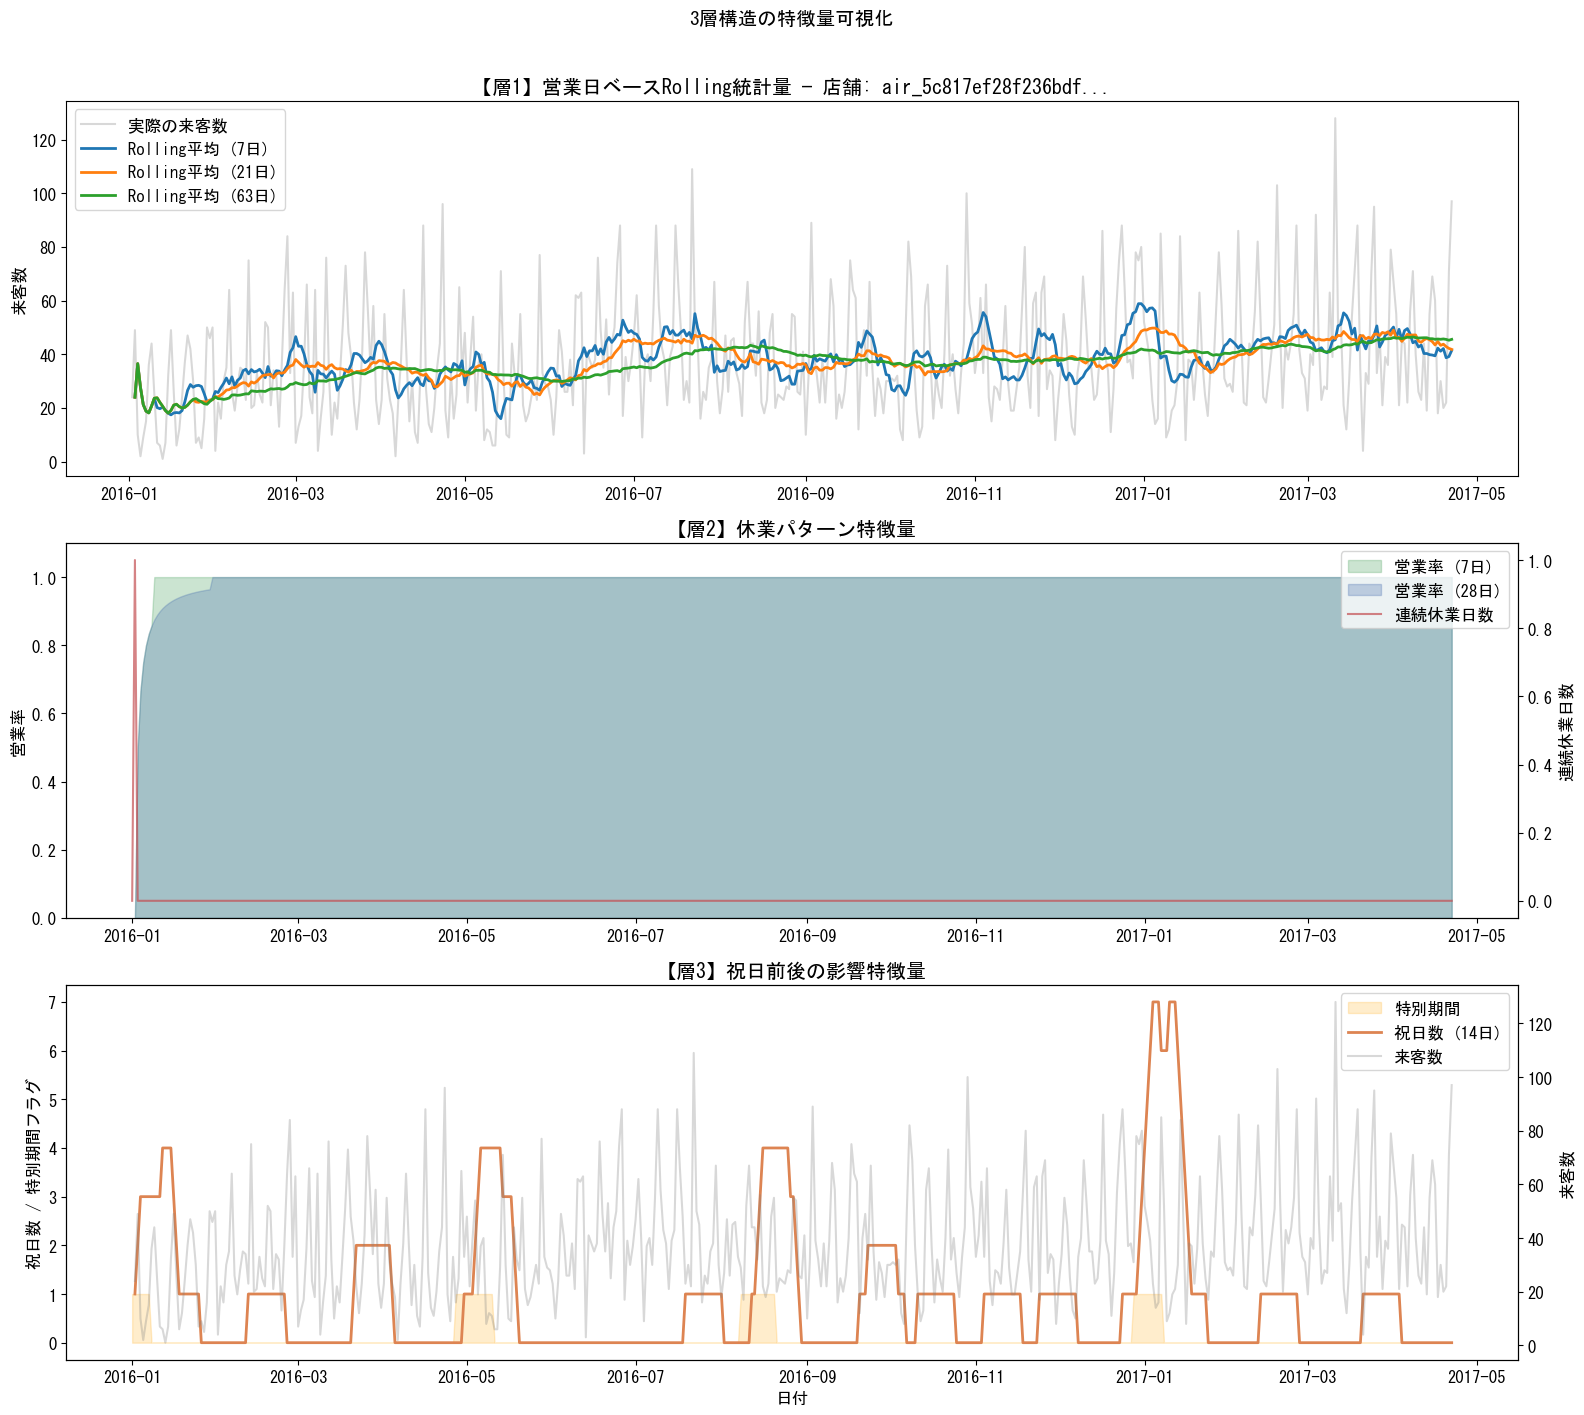

考察:
- 【層1】営業日ベースのRolling平均は、非営業日のNaNをスキップするため下方バイアスがない
- 【層2】営業率が低下する期間（正月・GW等）と連続休業日数の急上昇が対応
- 【層3】特別期間フラグと祝日数により、大型連休の前後効果を明示的に捉えられる


In [29]:
# Rolling統計量の可視化: 営業日ベースの効果確認
sample_store = air_visit.groupby('air_store_id')['visitors'].count().idxmax()
sample = grid_df[grid_df['air_store_id'] == sample_store].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# --- パネル1: Rolling統計量（営業日ベース） ---
axes[0].plot(sample['visit_date'], sample['visitors'], alpha=0.3, label='実際の来客数', color='gray')
axes[0].plot(sample['visit_date'], sample['rolling_mean_7'], label='Rolling平均 (7日)', linewidth=2)
axes[0].plot(sample['visit_date'], sample['rolling_mean_21'], label='Rolling平均 (21日)', linewidth=2)
axes[0].plot(sample['visit_date'], sample['rolling_mean_63'], label='Rolling平均 (63日)', linewidth=2)
axes[0].set_title(f'【層1】営業日ベースRolling統計量 — 店舗: {sample_store[:25]}...')
axes[0].set_ylabel('来客数')
axes[0].legend()

# --- パネル2: 休業パターン特徴量 ---
ax2a = axes[1]
ax2b = ax2a.twinx()
ax2a.fill_between(sample['visit_date'], sample['open_ratio_7'], alpha=0.3, color='#55A868', label='営業率 (7日)')
ax2a.fill_between(sample['visit_date'], sample['open_ratio_28'], alpha=0.3, color='#4C72B0', label='営業率 (28日)')
ax2a.set_ylabel('営業率')
ax2a.set_ylim(0, 1.1)
ax2b.plot(sample['visit_date'], sample['closed_streak'], color='#C44E52', alpha=0.7, label='連続休業日数')
ax2b.set_ylabel('連続休業日数')
ax2a.set_title('【層2】休業パターン特徴量')
lines1, labels1 = ax2a.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2a.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# --- パネル3: 祝日前後の影響特徴量 ---
axes[2].fill_between(sample['visit_date'], sample['is_near_special_period'], alpha=0.2, color='orange', label='特別期間')
axes[2].plot(sample['visit_date'], sample['holiday_count_14'], color='#DD8452', linewidth=2, label='祝日数 (14日)')
ax3b = axes[2].twinx()
ax3b.plot(sample['visit_date'], sample['visitors'], alpha=0.3, color='gray', label='来客数')
ax3b.set_ylabel('来客数')
axes[2].set_title('【層3】祝日前後の影響特徴量')
axes[2].set_ylabel('祝日数 / 特別期間フラグ')
axes[2].set_xlabel('日付')
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle('3層構造の特徴量可視化', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('考察:')
print('- 【層1】営業日ベースのRolling平均は、非営業日のNaNをスキップするため下方バイアスがない')
print('- 【層2】営業率が低下する期間（正月・GW等）と連続休業日数の急上昇が対応')
print('- 【層3】特別期間フラグと祝日数により、大型連休の前後効果を明示的に捉えられる')

In [30]:
# Rolling/ラグ + 休業パターン + 祝日特徴量を結合して効果を検証
merge_cols = ['air_store_id', 'visit_date'] + rolling_cols + closure_cols + holiday_cols
train_tsr = train_ts.merge(grid_df[merge_cols], on=['air_store_id', 'visit_date'], how='left')
valid_tsr = valid_ts.merge(grid_df[merge_cols], on=['air_store_id', 'visit_date'], how='left')

# ジャンル交互作用特徴量は train_ts/valid_ts に既に追加済み
# → merge後の train_tsr/valid_tsr にも自動的に含まれる

# store_features をジャンル交互作用込みに更新
store_features_with_genre = store_features + genre_interaction_cols

# --- ステップ3a: 層1のみ（Rolling/ラグ） ---
features_3a = store_features_with_genre + rolling_cols
lgb_data3a = lgb.Dataset(train_tsr[features_3a], label=np.log1p(train_tsr['visitors']))
model_3a = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'verbose': -1, 'random_state': SEED,
     'num_leaves': 63, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8},
    lgb_data3a, num_boost_round=1000
)
pred_3a = np.expm1(model_3a.predict(valid_tsr[features_3a]))
score_rolling = rmsle(valid_tsr['visitors'], pred_3a)

# --- ステップ3b: 層1 + 層2 + 層3（全特徴量） ---
all_features = store_features_with_genre + rolling_cols + closure_cols + holiday_cols
lgb_data3b = lgb.Dataset(train_tsr[all_features], label=np.log1p(train_tsr['visitors']))
model_all = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'verbose': -1, 'random_state': SEED,
     'num_leaves': 63, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8},
    lgb_data3b, num_boost_round=1000
)
pred_3b = np.expm1(model_all.predict(valid_tsr[all_features]))
score_all = rmsle(valid_tsr['visitors'], pred_3b)

print(f'【ステップ3a】店舗統計 + ジャンル交互作用 + Rolling/ラグ（層1のみ） → RMSLE: {score_rolling:.5f}')
print(f'  ステップ2bからの改善幅: {score_genre_int - score_rolling:.5f}')
print(f'\n【ステップ3b】全特徴量（層1 + 層2 + 層3） → RMSLE: {score_all:.5f}')
print(f'  ステップ3aからの改善幅: {score_rolling - score_all:.5f}')
print(f'  ステップ2bからの改善幅: {score_genre_int - score_all:.5f}')
print(f'  使用特徴量数: {len(all_features)}個')
print(f'\n→ 休業パターン・祝日特徴量（層2+3）の追加による効果を確認。')

【ステップ3a】店舗統計 + ジャンル交互作用 + Rolling/ラグ（層1のみ） → RMSLE: 0.51815
  ステップ2bからの改善幅: 0.04457

【ステップ3b】全特徴量（層1 + 層2 + 層3） → RMSLE: 0.51636
  ステップ3aからの改善幅: 0.00179
  ステップ2bからの改善幅: 0.04636
  使用特徴量数: 53個

→ 休業パターン・祝日特徴量（層2+3）の追加による効果を確認。


---
## 6.5 店舗別データカバレッジ分析 & 時系列CV評価関数の定義

### 欠損日の扱い

`air_visit_data.csv` は来客があった日のみ記録されており、欠損日は**行ごと存在しない**。
`grid_df` では全店舗×全日付のグリッドを作成し、データがない日は `visitors=NaN` / `is_open=0` としているが、
この「欠損」には以下の3種類が混在している：

| 種類 | 原因 | Rolling/統計量への影響 |
|------|------|----------------------|
| **データ開始前** | 店舗がまだ記録を開始していない | 営業実績がないため統計量算出の対象外にすべき |
| **定休日** | 定期的な休業（毎週月曜等） | 01 EDAで検出済み。`is_open=0` で正しい |
| **不定期ギャップ** | 長期休暇・改装・データ未記録 | 「休業」か「未記録」か不明。現行は休業扱い |

### 対応方針

1. **店舗ごとの「有効期間」を定義**: 初回記録日〜最終記録日を各店舗のデータ有効期間とする
2. **有効期間外は除外**: Rolling/store_statsの算出対象から除外（grid_dfのvisitorsをNaNに維持）
3. **有効期間内のギャップ**: 定休日パターン（01 EDA）と一致→休業、不一致→不明だが現行ルール(休業扱い)を維持
4. **CVフォールドの最低観測数**: 各フォールドで店舗の観測数が少なすぎる場合はその店舗を除外

=== 店舗別データカバレッジ ===
  店舗数: 829

  --- 初回記録日の分布 ---
  最早: 2016-01-01
  最遅: 2017-03-07
  中央値: 2016-07-01

  --- 有効期間の日数 ---
  最短: 47日
  最長: 478日
  平均: 357日

  --- カバレッジ率（記録日数/有効期間） ---
  平均: 85.0%
  最低: 13.6%
  25%ile: 80.0%
  中央値: 85.9%

  --- ギャップ日数（有効期間内の欠損日） ---
  ギャップ0日（完全記録）: 11店舗
  ギャップ1〜30日: 302店舗
  ギャップ31〜90日: 387店舗
  ギャップ91日以上: 129店舗


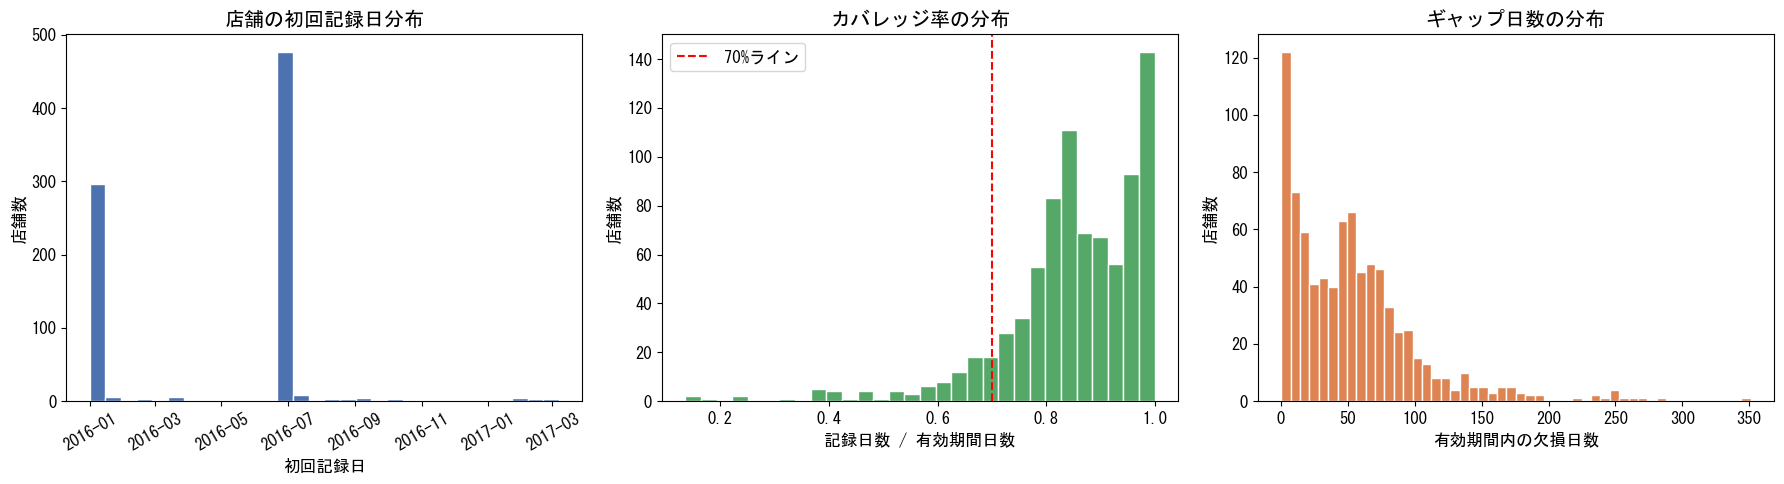


=== CVフォールドでの店舗カバレッジ確認 ===
  データ有効期間が短い店舗は、早いフォールドで学習データが不足する可能性あり
  Fold 1 (val_start=2016-04-23): 直近3ヶ月で30日以上の学習データがある店舗 = 305/829
  Fold 2 (val_start=2016-07-16): 直近3ヶ月で30日以上の学習データがある店舗 = 315/829
  Fold 3 (val_start=2016-10-15): 直近3ヶ月で30日以上の学習データがある店舗 = 804/829
  Fold 4 (val_start=2016-12-16): 直近3ヶ月で30日以上の学習データがある店舗 = 815/829
  Fold 5 (val_start=2017-03-15): 直近3ヶ月で30日以上の学習データがある店舗 = 819/829


In [31]:
# ============================================================
# 店舗別データカバレッジ分析
# ============================================================
# air_visit_data.csv は来客があった日のみ記録 → 欠損日は行ごと存在しない
# 店舗ごとに「いつからいつまでデータがあるか」「ギャップはどのくらいか」を把握する
MIN_TRAIN_DAYS = 30  # 最低学習期間（日）— cell 19でも使用

store_coverage = air_visit.groupby('air_store_id').agg(
    first_date=('visit_date', 'min'),
    last_date=('visit_date', 'max'),
    n_records=('visit_date', 'count'),
    n_unique_dates=('visit_date', 'nunique'),
).reset_index()

# 有効期間（初回〜最終記録日）の日数
store_coverage['active_days'] = (store_coverage['last_date'] - store_coverage['first_date']).dt.days + 1
# カバレッジ率 = 実際の記録日数 / 有効期間日数
store_coverage['coverage_rate'] = store_coverage['n_unique_dates'] / store_coverage['active_days']
# ギャップ日数（有効期間内で記録がない日）
store_coverage['gap_days'] = store_coverage['active_days'] - store_coverage['n_unique_dates']

print('=== 店舗別データカバレッジ ===')
print(f'  店舗数: {len(store_coverage)}')
print(f'\n  --- 初回記録日の分布 ---')
print(f'  最早: {store_coverage["first_date"].min().date()}')
print(f'  最遅: {store_coverage["first_date"].max().date()}')
print(f'  中央値: {store_coverage["first_date"].median().date()}')

print(f'\n  --- 有効期間の日数 ---')
print(f'  最短: {store_coverage["active_days"].min()}日')
print(f'  最長: {store_coverage["active_days"].max()}日')
print(f'  平均: {store_coverage["active_days"].mean():.0f}日')

print(f'\n  --- カバレッジ率（記録日数/有効期間） ---')
print(f'  平均: {store_coverage["coverage_rate"].mean():.1%}')
print(f'  最低: {store_coverage["coverage_rate"].min():.1%}')
print(f'  25%ile: {store_coverage["coverage_rate"].quantile(0.25):.1%}')
print(f'  中央値: {store_coverage["coverage_rate"].median():.1%}')

print(f'\n  --- ギャップ日数（有効期間内の欠損日） ---')
print(f'  ギャップ0日（完全記録）: {(store_coverage["gap_days"] == 0).sum()}店舗')
print(f'  ギャップ1〜30日: {((store_coverage["gap_days"] > 0) & (store_coverage["gap_days"] <= 30)).sum()}店舗')
print(f'  ギャップ31〜90日: {((store_coverage["gap_days"] > 30) & (store_coverage["gap_days"] <= 90)).sum()}店舗')
print(f'  ギャップ91日以上: {(store_coverage["gap_days"] > 90).sum()}店舗')

# 可視化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 初回記録日の分布
axes[0].hist(store_coverage['first_date'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('店舗の初回記録日分布')
axes[0].set_xlabel('初回記録日')
axes[0].set_ylabel('店舗数')
axes[0].tick_params(axis='x', rotation=30)

# カバレッジ率の分布
axes[1].hist(store_coverage['coverage_rate'], bins=30, color='#55A868', edgecolor='white')
axes[1].set_title('カバレッジ率の分布')
axes[1].set_xlabel('記録日数 / 有効期間日数')
axes[1].set_ylabel('店舗数')
axes[1].axvline(x=0.7, color='red', linestyle='--', label='70%ライン')
axes[1].legend()

# ギャップ日数の分布
axes[2].hist(store_coverage['gap_days'], bins=50, color='#DD8452', edgecolor='white')
axes[2].set_title('ギャップ日数の分布')
axes[2].set_xlabel('有効期間内の欠損日数')
axes[2].set_ylabel('店舗数')

plt.tight_layout()
plt.show()

# 店舗の有効期間をdict化（CV関数で使用）
store_first_date = store_coverage.set_index('air_store_id')['first_date'].to_dict()
store_last_date = store_coverage.set_index('air_store_id')['last_date'].to_dict()

# CVフォールド × 期間での使用可能フォールド数を確認
print(f'\n=== CVフォールドでの店舗カバレッジ確認 ===')
print(f'  データ有効期間が短い店舗は、早いフォールドで学習データが不足する可能性あり')
for i, fold in enumerate(eda_val_folds):
    val_start = pd.Timestamp(fold['val_start'])
    # 各期間で学習データが30日以上ある店舗数
    for period_label, period_days in [('15ヶ月', 456), ('12ヶ月', 365), ('6ヶ月', 183), ('3ヶ月', 91)]:
        train_start = val_start - pd.Timedelta(days=period_days)
        # 店舗の初回記録日がtrain_start以前 → 学習データあり
        n_stores_ok = sum(1 for sid, fd in store_first_date.items()
                         if fd <= train_start + pd.Timedelta(days=MIN_TRAIN_DAYS))
        if period_label == '3ヶ月':  # 最短期間のみ表示
            print(f'  Fold {i+1} (val_start={fold["val_start"]}): '
                  f'直近{period_label}で{MIN_TRAIN_DAYS}日以上の学習データがある店舗 = '
                  f'{n_stores_ok}/{len(store_first_date)}')

In [32]:
# ============================================================
# 共通の時系列CV評価関数
# ============================================================
# 01 EDAで設計したval_foldsを使って、各検証を5フォールドCVで実施する
#
# 【学習期間のリーク防止ルール】
#   1. 絶対日付禁止: 学習開始日は val_start からの相対日数で算出する
#   2. 「全期間」禁止: train_period_days=None の場合はセクション10で使用しない
#   3. 最低学習期間: 各フォールドで学習データが30日未満の場合はスキップ
#
# 【店舗別データ欠損の扱い】
#   air_visit_data.csvは来客日のみ記録→欠損日は行ごと存在しない。
#   各フォールドで店舗ごとの観測数が MIN_STORE_RECORDS 未満の場合、
#   その店舗は store_stats の信頼性が低いため除外する。
# ============================================================

MIN_TRAIN_DAYS = 30           # 最低学習期間（日）
MIN_STORE_RECORDS = 7         # フォールド内で店舗を使用する最低観測数

def build_fold_data(df, grid_df, fold, air_store, date_info, air_visit,
                    eda_genre_dow, eda_genre_holiday, eda_genre_reserve_coverage,
                    eda_genre_closure_pattern, train_start=None, train_period_days=None):
    """
    各フォールドに対して、リーク防止した特徴量付きデータを構築する。
    
    店舗別データ欠損への対応:
      - air_visit_data.csvは来客日のみ記録（欠損日は行ごと存在しない）
      - 各店舗のデータ開始日は異なる（遅い店舗は初期フォールドで学習データ不足）
      - フォールドのtrain期間内で観測数が MIN_STORE_RECORDS 未満の店舗は除外
      - これにより store_stats / store_dow の信頼性を担保する
    """
    val_start = pd.Timestamp(fold['val_start'])
    val_end = pd.Timestamp(fold['val_end'])
    
    # 学習開始日の決定
    if train_period_days is not None:
        effective_train_start = val_start - pd.Timedelta(days=train_period_days)
        train_mask = (df['visit_date'] >= effective_train_start) & (df['visit_date'] < val_start)
    elif train_start is not None:
        if pd.Timestamp(train_start) >= val_start:
            return None, None
        train_mask = (df['visit_date'] >= train_start) & (df['visit_date'] < val_start)
    else:
        train_mask = df['visit_date'] < val_start
    valid_mask = (df['visit_date'] >= val_start) & (df['visit_date'] <= val_end)
    
    fold_train = df[train_mask].copy()
    fold_valid = df[valid_mask].copy()
    
    if len(fold_train) == 0 or len(fold_valid) == 0:
        return None, None
    
    # 最低学習期間チェック
    train_days = (fold_train['visit_date'].max() - fold_train['visit_date'].min()).days + 1
    if train_days < MIN_TRAIN_DAYS:
        return None, None
    
    # --- 店舗別の観測数チェック ---
    # train期間内で観測数が少なすぎる店舗を除外
    store_record_counts = fold_train.groupby('air_store_id')['visit_date'].count()
    valid_stores = store_record_counts[store_record_counts >= MIN_STORE_RECORDS].index
    
    # train/validの両方に存在する店舗のみ残す
    common_stores = set(valid_stores) & set(fold_valid['air_store_id'].unique())
    fold_train = fold_train[fold_train['air_store_id'].isin(common_stores)].copy()
    fold_valid = fold_valid[fold_valid['air_store_id'].isin(common_stores)].copy()
    
    if len(fold_train) == 0 or len(fold_valid) == 0:
        return None, None
    
    # --- 時間特徴量 ---
    for d in [fold_train, fold_valid]:
        d['month'] = d['visit_date'].dt.month
        d['day'] = d['visit_date'].dt.day
        d['dow'] = d['visit_date'].dt.dayofweek
        d['week'] = d['visit_date'].dt.isocalendar().week.astype(int)
        d['is_weekend'] = (d['dow'] >= 5).astype(int)
        d['is_holiday'] = d['holiday_flg'].fillna(0).astype(int)
    
    # --- カテゴリエンコーディング ---
    for d in [fold_train, fold_valid]:
        d['genre_encoded'] = d['air_genre_name'].factorize()[0]
        d['area_encoded'] = d['air_area_name'].factorize()[0]
    
    # --- 店舗統計量（フォールドのtrainデータのみから算出） ---
    # ※ MIN_STORE_RECORDS以上の観測がある店舗のみ → 統計量の信頼性を担保
    fold_store_stats = fold_train.groupby('air_store_id')['visitors'].agg(
        ['mean', 'median', 'std', 'min', 'max', 'count']
    ).reset_index()
    fold_store_stats.columns = ['air_store_id', 'store_mean', 'store_median', 'store_std',
                                 'store_min', 'store_max', 'store_count']
    
    fold_train_dow = fold_train.copy()
    fold_train_dow['dow'] = fold_train_dow['visit_date'].dt.dayofweek
    fold_store_dow = fold_train_dow.groupby(['air_store_id', 'dow'])['visitors'].agg(
        ['mean', 'median']
    ).reset_index()
    fold_store_dow.columns = ['air_store_id', 'dow', 'store_dow_mean', 'store_dow_median']
    
    fold_genre_stats = fold_train.groupby('air_genre_name')['visitors'].agg(
        ['mean', 'median']
    ).reset_index()
    fold_genre_stats.columns = ['air_genre_name', 'genre_mean', 'genre_median']
    
    # 結合（既存の列を削除してからmerge）
    drop_cols = ['store_mean', 'store_median', 'store_std', 'store_min', 'store_max',
                 'store_count', 'store_dow_mean', 'store_dow_median', 'genre_mean', 'genre_median']
    for d in [fold_train, fold_valid]:
        d.drop(columns=[c for c in drop_cols if c in d.columns], inplace=True)
    
    fold_train = fold_train.merge(fold_store_stats, on='air_store_id', how='left')
    fold_train = fold_train.merge(fold_store_dow, on=['air_store_id', 'dow'], how='left')
    fold_train = fold_train.merge(fold_genre_stats, on='air_genre_name', how='left')
    
    fold_valid = fold_valid.merge(fold_store_stats, on='air_store_id', how='left')
    fold_valid = fold_valid.merge(fold_store_dow, on=['air_store_id', 'dow'], how='left')
    fold_valid = fold_valid.merge(fold_genre_stats, on='air_genre_name', how='left')
    
    # --- ジャンル交互作用特徴量 ---
    genre_dow_stacked = eda_genre_dow.copy()
    if not all(isinstance(c, (int, np.integer)) for c in genre_dow_stacked.columns):
        genre_dow_stacked.columns = range(len(genre_dow_stacked.columns))
    _genre_dow_lookup = genre_dow_stacked.stack().reset_index()
    _genre_dow_lookup.columns = ['air_genre_name', 'dow', 'genre_dow_mean']
    _genre_dow_lookup['dow'] = _genre_dow_lookup['dow'].astype(int)
    
    _genre_holiday_lookup = eda_genre_holiday[['ratio']].reset_index()
    _genre_holiday_lookup.columns = ['air_genre_name', 'genre_holiday_ratio']
    
    _genre_reserve_lookup = eda_genre_reserve_coverage[['reserve_coverage_mean']].reset_index()
    _genre_reserve_lookup.columns = ['air_genre_name', 'genre_reserve_coverage']
    
    _genre_closure_lookup = pd.DataFrame([
        {'air_genre_name': genre, 'genre_closure_days': info['avg_closure_days_per_week']}
        for genre, info in eda_genre_closure_pattern.items()
    ])
    
    genre_int_drop = ['genre_dow_mean', 'genre_holiday_ratio', 'genre_reserve_coverage',
                      'genre_closure_days', 'store_popularity_in_genre']
    for d in [fold_train, fold_valid]:
        d['dow'] = d['dow'].astype(int)
        d.drop(columns=[c for c in genre_int_drop if c in d.columns], inplace=True)
        
        d_m = d.merge(_genre_dow_lookup, on=['air_genre_name', 'dow'], how='left')
        d['genre_dow_mean'] = d_m['genre_dow_mean'].values
        
        d_m = d.merge(_genre_holiday_lookup, on='air_genre_name', how='left')
        d['genre_holiday_ratio'] = d_m['genre_holiday_ratio'].values
        
        d_m = d.merge(_genre_reserve_lookup, on='air_genre_name', how='left')
        d['genre_reserve_coverage'] = d_m['genre_reserve_coverage'].values
        
        d_m = d.merge(_genre_closure_lookup, on='air_genre_name', how='left')
        d['genre_closure_days'] = d_m['genre_closure_days'].values
        
        d['store_popularity_in_genre'] = d['store_mean'] / d['genre_mean']
    
    # --- Rolling/ラグ/休業/祝日特徴量はgrid_dfから結合 ---
    merge_cols = ['air_store_id', 'visit_date'] + rolling_cols + closure_cols + holiday_cols
    fold_train = fold_train.merge(grid_df[merge_cols], on=['air_store_id', 'visit_date'], how='left')
    fold_valid = fold_valid.merge(grid_df[merge_cols], on=['air_store_id', 'visit_date'], how='left')
    
    return fold_train, fold_valid


def evaluate_with_tscv(df, grid_df, features, lgb_params, val_folds,
                       air_store, date_info, air_visit,
                       eda_genre_dow, eda_genre_holiday,
                       eda_genre_reserve_coverage, eda_genre_closure_pattern,
                       train_start=None, train_period_days=None,
                       nan_fill_fn=None,
                       extra_grid=None, extra_cols=None):
    """
    01 EDAで設計したval_foldsを使った時系列CV評価。
    
    Returns: cv_mean, cv_std, fold_scores, n_folds_used
    """
    fold_scores = []
    
    for i, fold in enumerate(val_folds):
        fold_train, fold_valid = build_fold_data(
            df, grid_df, fold, air_store, date_info, air_visit,
            eda_genre_dow, eda_genre_holiday,
            eda_genre_reserve_coverage, eda_genre_closure_pattern,
            train_start=train_start,
            train_period_days=train_period_days
        )
        
        if fold_train is None:
            continue
        
        # 追加Rolling特徴量がある場合は結合
        if extra_grid is not None and extra_cols is not None:
            merge_extra = ['air_store_id', 'visit_date'] + extra_cols
            fold_train = fold_train.merge(extra_grid[merge_extra],
                                          on=['air_store_id', 'visit_date'], how='left')
            fold_valid = fold_valid.merge(extra_grid[merge_extra],
                                          on=['air_store_id', 'visit_date'], how='left')
        
        available_feats = [f for f in features if f in fold_train.columns]
        X_tr = fold_train[available_feats]
        y_tr = np.log1p(fold_train['visitors'])
        X_va = fold_valid[available_feats]
        y_va_raw = fold_valid['visitors']
        
        if nan_fill_fn is not None:
            X_tr = nan_fill_fn(X_tr.copy())
            X_va = nan_fill_fn(X_va.copy())
        
        dtr = lgb.Dataset(X_tr, label=y_tr)
        dva = lgb.Dataset(X_va, label=np.log1p(y_va_raw), reference=dtr)
        
        m = lgb.train(
            lgb_params, dtr, num_boost_round=2000,
            valid_sets=[dva], valid_names=['valid'],
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
        )
        
        pred = np.expm1(m.predict(X_va))
        score = rmsle(y_va_raw, pred)
        fold_scores.append(score)
    
    if len(fold_scores) == 0:
        return np.nan, np.nan, [], 0
    
    cv_mean = np.mean(fold_scores)
    cv_std = np.std(fold_scores)
    return cv_mean, cv_std, fold_scores, len(fold_scores)


def is_significant(mean1, std1, mean2, std2):
    """2つの設定間に有意差があるか判定（±1σの区間が重ならない）"""
    return (mean1 + std1 < mean2 - std2) or (mean2 + std2 < mean1 - std1)


print('=== 時系列CV評価関数を定義 ===')
print(f'  使用フォールド数: {len(eda_val_folds)}')
print(f'  最低学習期間: {MIN_TRAIN_DAYS}日')
print(f'  最低店舗観測数: {MIN_STORE_RECORDS}件/フォールド')
print(f'\n  【リーク防止ルール】')
print(f'  1. 学習開始日は val_start からの相対日数で算出')
print(f'  2.「全期間」(制限なし)は学習期間検証で使用しない')
print(f'  3. store_stats / genre_stats は各フォールドのtrainデータのみから再計算')
print(f'  4. Rolling特徴量は shift(1) 適用済みの grid_df から結合（未来リークなし）')
print(f'\n  【店舗別データ欠損への対応】')
print(f'  ・欠損日は行ごと存在しない（来客日のみ記録）')
print(f'  ・各店舗のデータ開始日は異なる')
print(f'  ・フォールドのtrain期間内で観測数 < {MIN_STORE_RECORDS} の店舗は除外')
print(f'  ・これにより store_stats の信頼性を担保')

=== 時系列CV評価関数を定義 ===
  使用フォールド数: 5
  最低学習期間: 30日
  最低店舗観測数: 7件/フォールド

  【リーク防止ルール】
  1. 学習開始日は val_start からの相対日数で算出
  2.「全期間」(制限なし)は学習期間検証で使用しない
  3. store_stats / genre_stats は各フォールドのtrainデータのみから再計算
  4. Rolling特徴量は shift(1) 適用済みの grid_df から結合（未来リークなし）

  【店舗別データ欠損への対応】
  ・欠損日は行ごと存在しない（来客日のみ記録）
  ・各店舗のデータ開始日は異なる
  ・フォールドのtrain期間内で観測数 < 7 の店舗は除外
  ・これにより store_stats の信頼性を担保


---
## 7. 特徴量の段階的効果比較

=== 全ステップの時系列CV評価を実行中... ===
  ①時間のみ: CV=0.80146 ± 0.01071 (5フォールド)
  ②+店舗統計: CV=0.56541 ± 0.02515 (5フォールド)
  ②b+ジャンル交互作用: CV=0.56433 ± 0.02471 (5フォールド)
  ③+Rolling/ラグ(層1): CV=0.54698 ± 0.02709 (5フォールド)
  ④+休業/祝日(層2+3): CV=0.54520 ± 0.02648 (5フォールド)

=== 特徴量カテゴリ別の段階的効果（CV平均±std） ===
          特徴量セット  RMSLE(単一)  特徴量数      改善幅     CV平均   CV std
           ①時間のみ   0.819485     6 0.000000 0.801460 0.010712
          ②+店舗統計   0.561871    20 0.257614 0.565413 0.025153
     ②b+ジャンル交互作用   0.562721    25 0.000851 0.564329 0.024706
③+Rolling/ラグ(層1)   0.518151    42 0.044570 0.546976 0.027085
   ④+休業/祝日(層2+3)   0.516358    53 0.001793 0.545199 0.026480


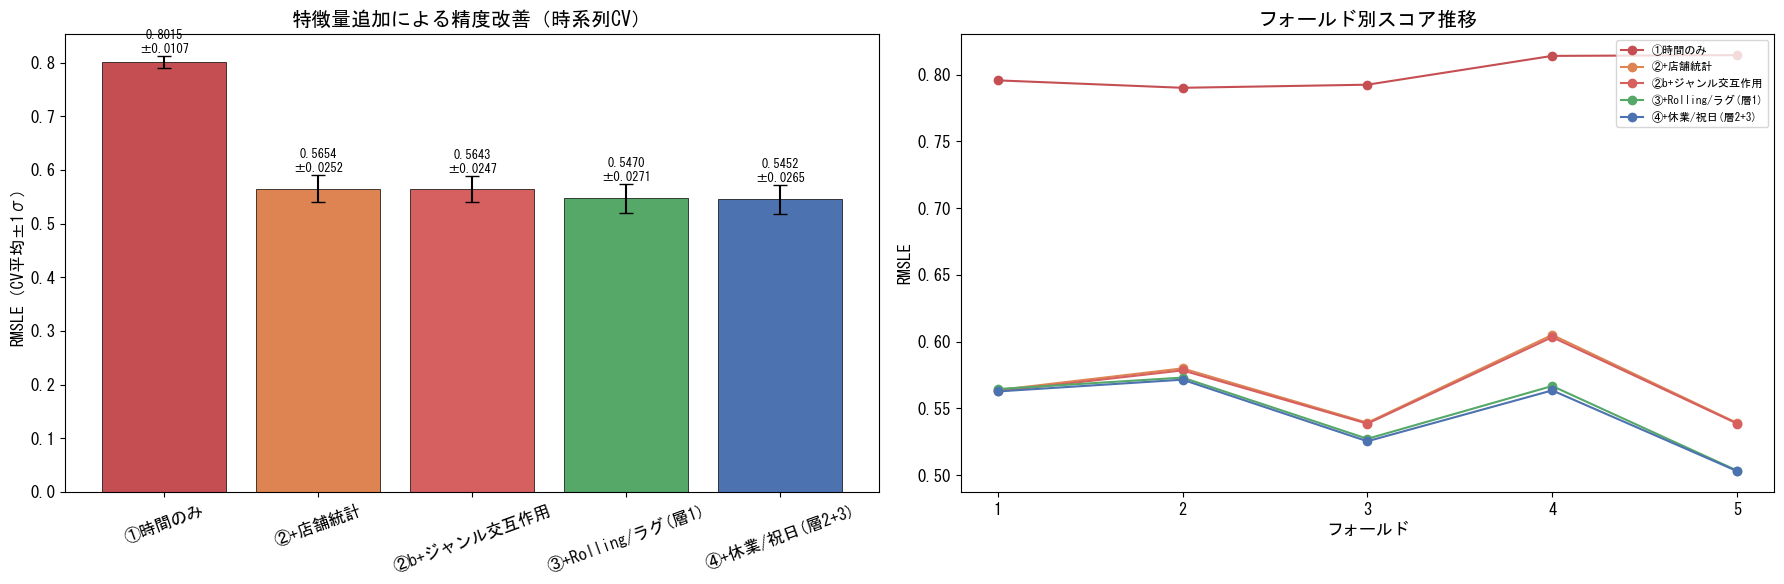

In [33]:
# 5ステップの結果を一覧表にまとめる（単一分割 + CV結果）
results = pd.DataFrame({
    '特徴量セット': ['①時間のみ', '②+店舗統計', '②b+ジャンル交互作用',
                     '③+Rolling/ラグ(層1)', '④+休業/祝日(層2+3)'],
    'RMSLE(単一)': [score_time, score_store, score_genre_int, score_rolling, score_all],
    '特徴量数': [len(time_features), len(store_features), len(genre_int_features),
                len(features_3a), len(all_features)]
})
results['改善幅'] = results['RMSLE(単一)'].diff().fillna(0).abs()

# 全ステップのCV評価
print('=== 全ステップの時系列CV評価を実行中... ===')
lgb_cv_params = {
    'objective': 'regression', 'metric': 'rmse', 'verbose': -1,
    'random_state': SEED, 'num_leaves': 63, 'learning_rate': 0.02,
    'subsample': 0.8, 'colsample_bytree': 0.8,
}

step_cv_results = {}
step_configs = [
    ('①時間のみ', time_features),
    ('②+店舗統計', store_features),
    ('②b+ジャンル交互作用', genre_int_features),
    ('③+Rolling/ラグ(層1)', features_3a),
    ('④+休業/祝日(層2+3)', all_features),
]

for step_name, feats in step_configs:
    cv_m, cv_s, cv_scores, n_used = evaluate_with_tscv(
        df, grid_df, feats, lgb_cv_params,
        eda_val_folds, air_store, date_info, air_visit,
        eda_genre_dow, eda_genre_holiday, eda_genre_reserve_coverage, eda_genre_closure_pattern
    )
    step_cv_results[step_name] = {'mean': cv_m, 'std': cv_s, 'scores': cv_scores}
    print(f'  {step_name}: CV={cv_m:.5f} ± {cv_s:.5f} ({n_used}フォールド)')

results['CV平均'] = [step_cv_results[n]['mean'] for n in results['特徴量セット']]
results['CV std'] = [step_cv_results[n]['std'] for n in results['特徴量セット']]

print(f'\n=== 特徴量カテゴリ別の段階的効果（CV平均±std） ===')
print(results.to_string(index=False))

# 棒グラフで可視化（エラーバー付き）
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = ['#C44E52', '#DD8452', '#D65F5F', '#55A868', '#4C72B0']
cv_means = results['CV平均'].values
cv_stds = results['CV std'].values

# CV RMSLEの比較（エラーバー付き）
bars = axes[0].bar(results['特徴量セット'], cv_means, yerr=cv_stds,
                   color=colors, capsize=5, edgecolor='black', linewidth=0.5)
for bar, mean, std in zip(bars, cv_means, cv_stds):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
            f'{mean:.4f}\n±{std:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylabel('RMSLE（CV平均±1σ）')
axes[0].set_title('特徴量追加による精度改善（時系列CV）')
axes[0].tick_params(axis='x', rotation=20)

# フォールド別スコアの折れ線グラフ
for step_name, color in zip(results['特徴量セット'], colors):
    scores = step_cv_results[step_name]['scores']
    axes[1].plot(range(1, len(scores)+1), scores, 'o-', color=color, label=step_name, markersize=6)
axes[1].set_xlabel('フォールド')
axes[1].set_ylabel('RMSLE')
axes[1].set_title('フォールド別スコア推移')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].set_xticks(range(1, len(eda_val_folds)+1))

plt.tight_layout()
plt.show()

---
## 8. 特徴量重要度の分析

全特徴量を使ったモデルから、各特徴量がどれだけ予測に貢献しているかを確認する。

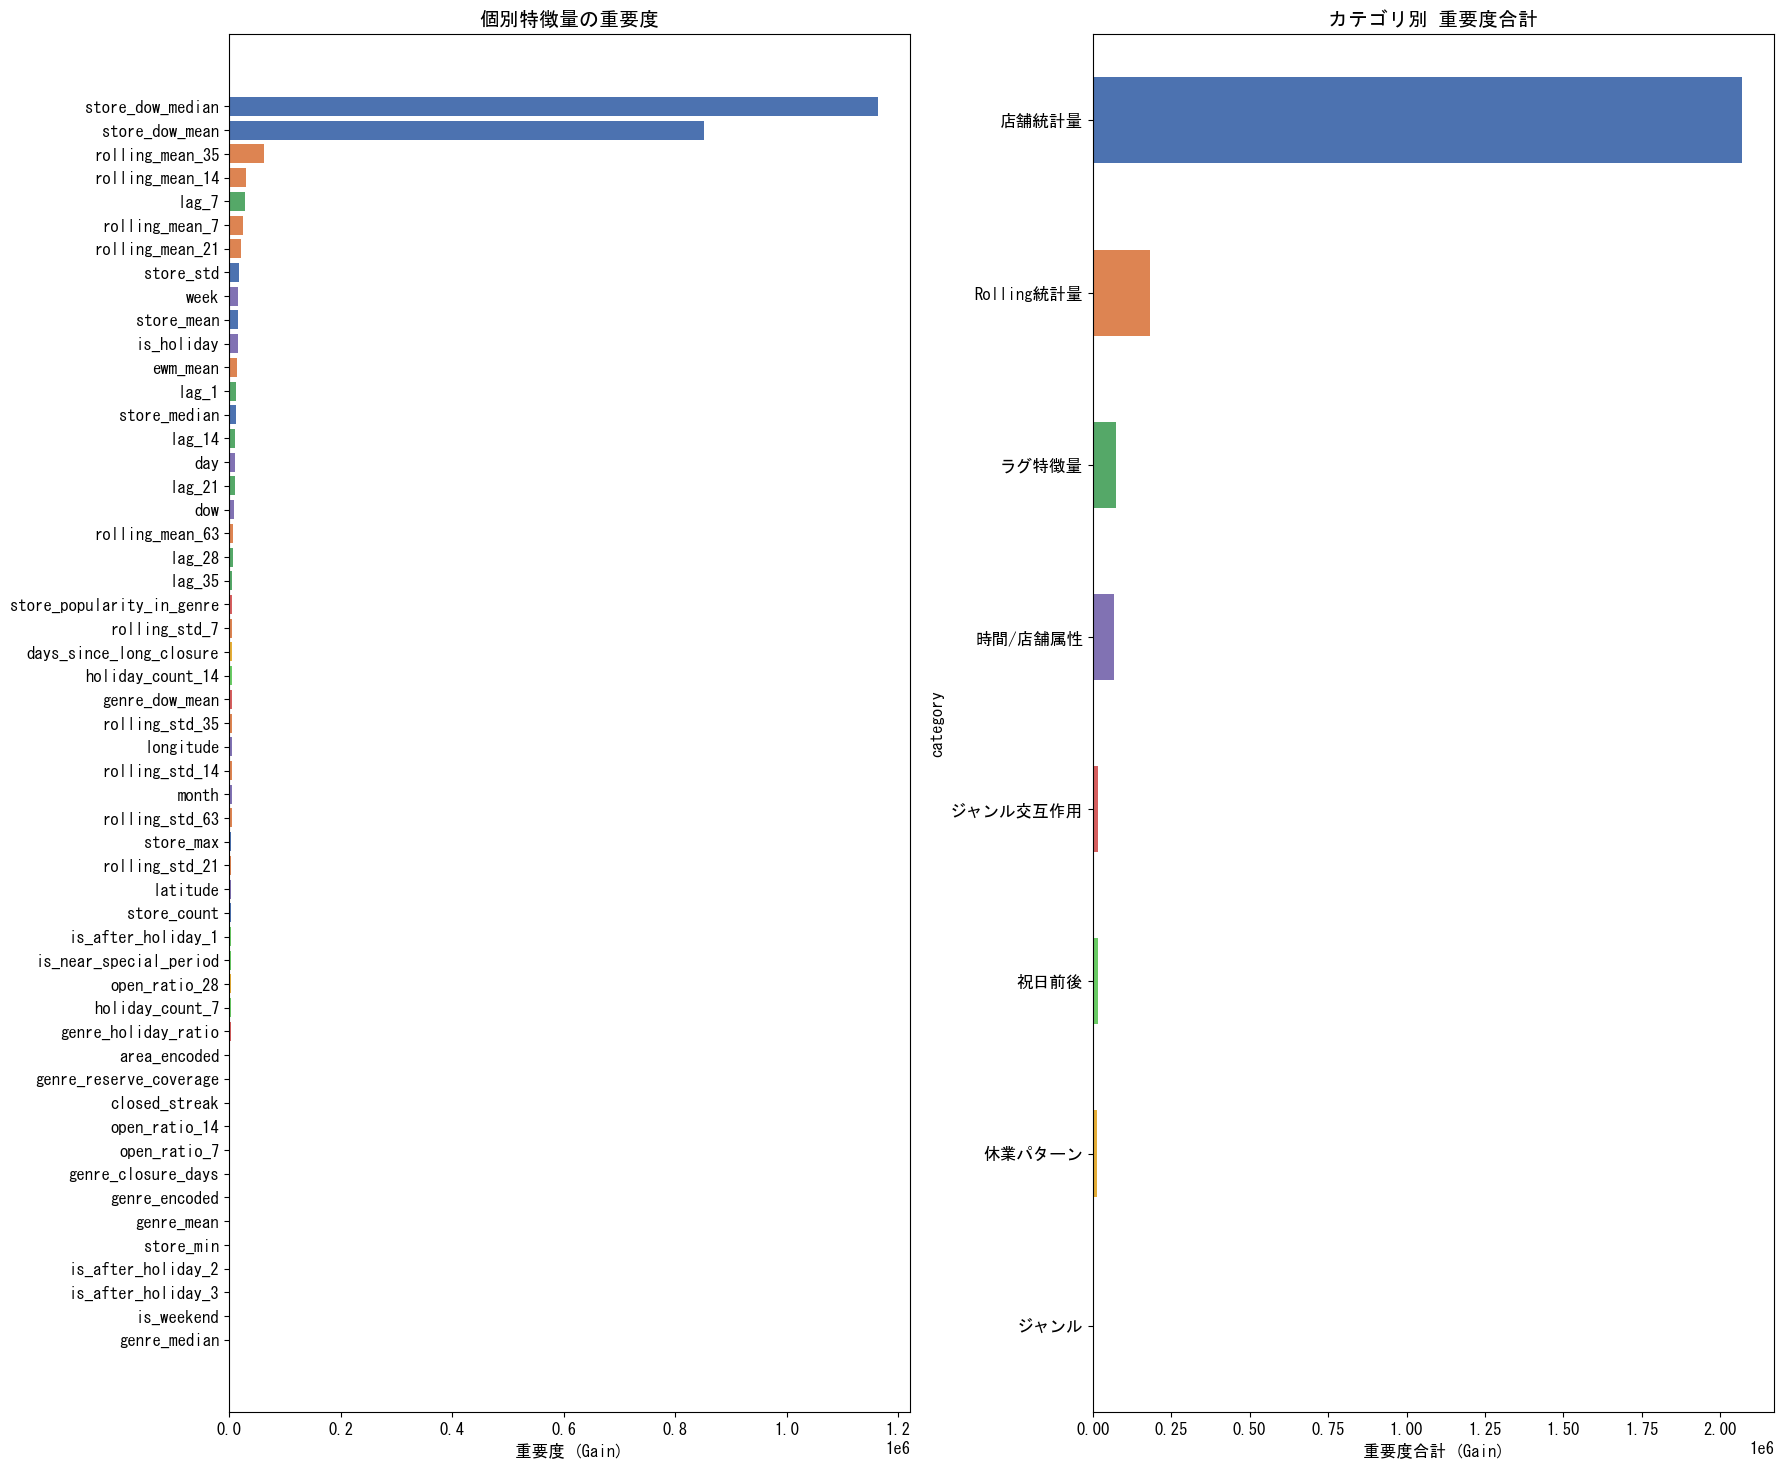


=== 上位15特徴量 ===
  [店舗統計量       ] store_dow_median: 1163261
  [店舗統計量       ] store_dow_mean: 851350
  [Rolling統計量  ] rolling_mean_35: 61832
  [Rolling統計量  ] rolling_mean_14: 29519
  [ラグ特徴量       ] lag_7: 28628
  [Rolling統計量  ] rolling_mean_7: 25417
  [Rolling統計量  ] rolling_mean_21: 21326
  [店舗統計量       ] store_std: 17195
  [時間/店舗属性     ] week: 16353
  [店舗統計量       ] store_mean: 15263
  [時間/店舗属性     ] is_holiday: 15118
  [Rolling統計量  ] ewm_mean: 13735
  [ラグ特徴量       ] lag_1: 11787
  [店舗統計量       ] store_median: 11685
  [ラグ特徴量       ] lag_14: 11171

=== カテゴリ別重要度 ===
  店舗統計量           :  2068260 ( 84.7%) [8特徴量]
  Rolling統計量      :   182327 (  7.5%) [11特徴量]
  ラグ特徴量           :    73924 (  3.0%) [6特徴量]
  時間/店舗属性         :    67476 (  2.8%) [9特徴量]
  ジャンル交互作用        :    17231 (  0.7%) [5特徴量]
  祝日前後            :    16463 (  0.7%) [6特徴量]
  休業パターン          :    13171 (  0.5%) [5特徴量]
  ジャンル            :     2709 (  0.1%) [3特徴量]


In [34]:
# 特徴量重要度の計算と可視化
importance = pd.DataFrame({
    'feature': all_features,
    'importance': model_all.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)

# カテゴリ分類（ジャンル交互作用を追加）
def categorize_feature(name):
    if name.startswith('rolling_') or name.startswith('ewm_'):
        return 'Rolling統計量'
    elif name.startswith('lag_'):
        return 'ラグ特徴量'
    elif name.startswith(('open_ratio_', 'closed_streak', 'days_since_')):
        return '休業パターン'
    elif name.startswith(('is_after_holiday_', 'holiday_count_', 'is_near_special')):
        return '祝日前後'
    elif name in ('genre_dow_mean', 'genre_holiday_ratio', 'genre_reserve_coverage',
                  'genre_closure_days', 'store_popularity_in_genre'):
        return 'ジャンル交互作用'
    elif name.startswith('store_'):
        return '店舗統計量'
    elif name.startswith('genre_'):
        return 'ジャンル'
    else:
        return '時間/店舗属性'

importance['category'] = importance['feature'].apply(categorize_feature)

fig, axes = plt.subplots(1, 2, figsize=(18, max(10, len(all_features) * 0.28)))

# 個別特徴量の重要度（色分け）
color_map = {
    'Rolling統計量': '#DD8452', 'ラグ特徴量': '#55A868',
    '店舗統計量': '#4C72B0', 'ジャンル': '#C44E52', '時間/店舗属性': '#8172B3',
    '休業パターン': '#E5AE38', '祝日前後': '#6ACC65',
    'ジャンル交互作用': '#D65F5F',
}
colors = importance['category'].map(color_map)
axes[0].barh(importance['feature'], importance['importance'], color=colors)
axes[0].set_xlabel('重要度 (Gain)')
axes[0].set_title('個別特徴量の重要度')

# カテゴリ別の合計重要度
cat_imp = importance.groupby('category')['importance'].sum().sort_values()
cat_colors = [color_map.get(c, 'gray') for c in cat_imp.index]
cat_imp.plot(kind='barh', ax=axes[1], color=cat_colors)
axes[1].set_xlabel('重要度合計 (Gain)')
axes[1].set_title('カテゴリ別 重要度合計')

plt.tight_layout()
plt.show()

# 上位15特徴量を表示
print('\n=== 上位15特徴量 ===')
for _, row in importance.tail(15).iloc[::-1].iterrows():
    print(f'  [{row["category"]:12s}] {row["feature"]}: {row["importance"]:.0f}')

# カテゴリ別の寄与を確認
print('\n=== カテゴリ別重要度 ===')
all_total = importance['importance'].sum()
for cat in cat_imp.index[::-1]:
    cat_total = importance[importance['category'] == cat]['importance'].sum()
    n_feats = len(importance[importance['category'] == cat])
    print(f'  {cat:16s}: {cat_total:8.0f} ({cat_total/all_total*100:5.1f}%) [{n_feats}特徴量]')

---
## 9. 相関分析

主要特徴量と目的変数（来客数）の相関を確認し、特徴量間の冗長性も把握する。

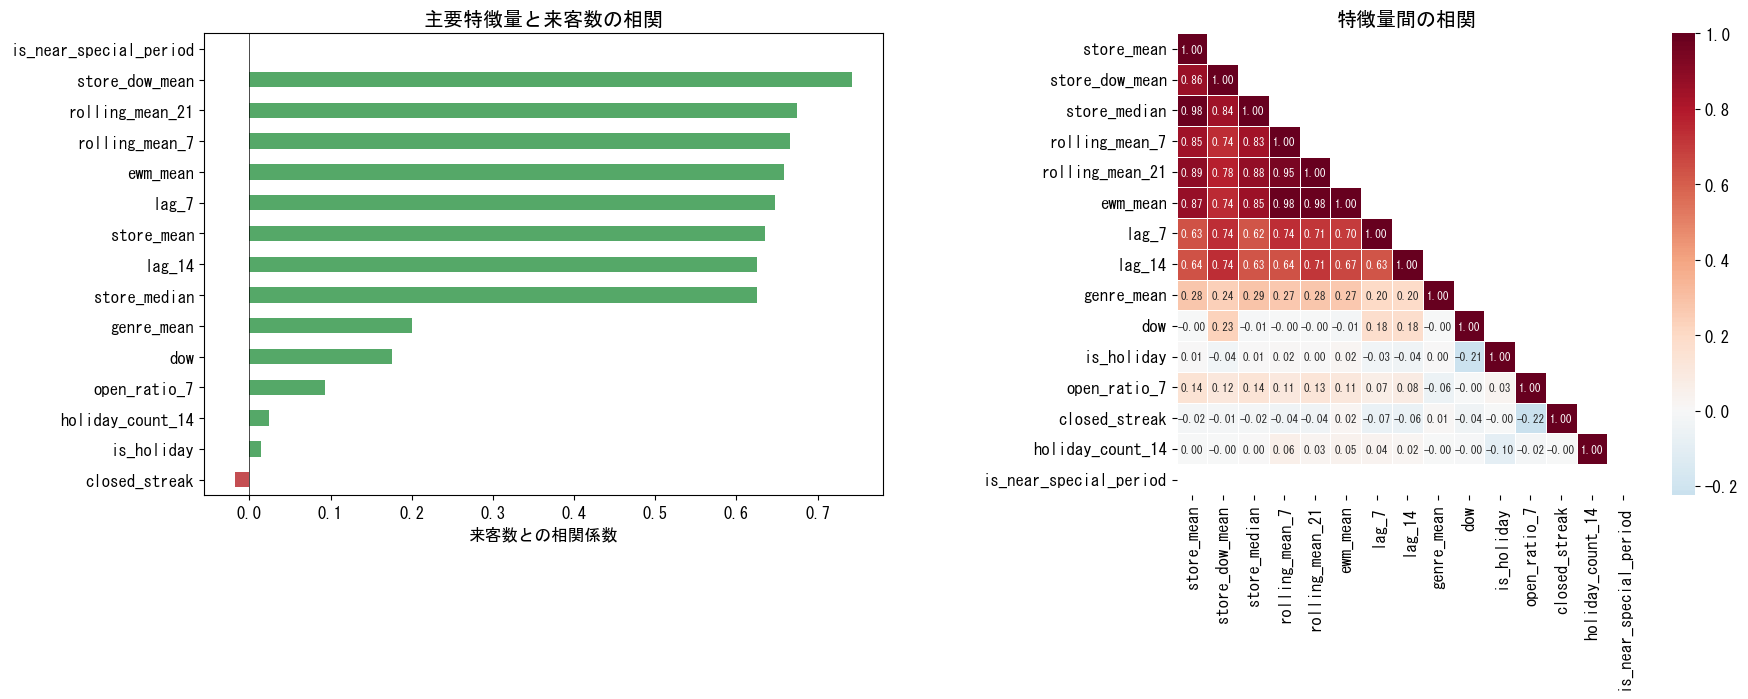

考察:
- store_dow_mean（店舗×曜日平均）が最も高い相関 → 店舗の曜日ごとの傾向が最も予測に有用
- Rolling統計量とラグ特徴量は互いに高い相関 → 一部は冗長だが、モデルは異なる情報を抽出
- open_ratio（営業率）は正の相関 → 営業日が多い期間ほど来客数も多い傾向
- closed_streak（連続休業日数）は負の相関 → 休業中は来客がない（直接的な関係）
- 曜日(dow)自体の相関は低い → 非線形な関係のため（金土が高い等）、木モデルでは有効


In [35]:
# 主要特徴量と目的変数の相関（新特徴量を含む）
key_features = ['store_mean', 'store_dow_mean', 'store_median',
                'rolling_mean_7', 'rolling_mean_21', 'ewm_mean',
                'lag_7', 'lag_14', 'genre_mean', 'dow', 'is_holiday',
                'open_ratio_7', 'closed_streak', 'holiday_count_14', 'is_near_special_period']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 目的変数との相関（棒グラフ）
corr_data = valid_tsr[key_features + ['visitors']].corr()['visitors'].drop('visitors').sort_values()
colors = ['#C44E52' if v < 0 else '#55A868' for v in corr_data]
corr_data.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_xlabel('来客数との相関係数')
axes[0].set_title('主要特徴量と来客数の相関')
axes[0].axvline(0, color='black', linewidth=0.5)

# 特徴量間の相関ヒートマップ
corr_matrix = valid_tsr[key_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], square=True, linewidths=0.5,
            annot_kws={'size': 8})
axes[1].set_title('特徴量間の相関')

plt.tight_layout()
plt.show()

print('考察:')
print('- store_dow_mean（店舗×曜日平均）が最も高い相関 → 店舗の曜日ごとの傾向が最も予測に有用')
print('- Rolling統計量とラグ特徴量は互いに高い相関 → 一部は冗長だが、モデルは異なる情報を抽出')
print('- open_ratio（営業率）は正の相関 → 営業日が多い期間ほど来客数も多い傾向')
print('- closed_streak（連続休業日数）は負の相関 → 休業中は来客がない（直接的な関係）')
print('- 曜日(dow)自体の相関は低い → 非線形な関係のため（金土が高い等）、木モデルでは有効')

---
## 10. 学習データ期間の検証

特徴量設計の前提として、**学習データにどの期間を含めるか**を決定する。

| 検証観点 | 意味 |
|---------|------|
| 古いデータを含める | データ量は多いがトレンド変化の影響を受ける |
| 直近データのみ | データ量は少ないが直近のパターンに忠実 |

上位解法では「直近6〜12ヶ月」が最も効果的とされることが多い。ここで最適期間を確定し、03以降のモデル設計で統一して使用する。

In [36]:
# 学習データ期間を変えて性能を比較（5フォールド時系列CV）
#
# 【リーク防止】
#   CVでは「val_startからの相対日数」で学習開始日を決定する。
#   「全期間」(制限なし)はフォールドごとに学習期間が異なるため使用しない。
#   最低学習期間: 30日（これ未満のフォールドはスキップ）。
#
# 【学習開始日と学習期間の区別】
#   ・学習期間(train_period_days): CVで検証する「何日分のデータを使うか」
#   ・学習開始日(train_start): 03で実際に使う絶対日付（VALID_STARTからの逆算で参考値として記録）

train_periods = [
    ('直近15ヶ月', 456),     # val_start - 456日（最大期間）
    ('直近12ヶ月', 365),     # val_start - 365日
    ('直近9ヶ月',  274),     # val_start - 274日
    ('直近6ヶ月',  183),     # val_start - 183日
    ('直近3ヶ月',  91),      # val_start - 91日
]

lgb_base_params = {
    'objective': 'regression', 'metric': 'rmse', 'verbose': -1,
    'random_state': SEED, 'num_leaves': 63, 'learning_rate': 0.02,
    'subsample': 0.8, 'colsample_bytree': 0.8,
}

# 03用の参考値: VALID_STARTからの絶対日付マッピング
single_train_starts = {}
for label, days in train_periods:
    start = pd.Timestamp(VALID_START) - pd.Timedelta(days=days)
    single_train_starts[label] = str(start.date())

# --- 参考: 単一分割での結果（VALID_START固定なので絶対日付でOK） ---
print('=== 単一分割での参考値 ===')
period_results_single = {}
for label, period_days in train_periods:
    start_date = single_train_starts[label]
    mask = train_tsr['visit_date'] >= start_date
    X_tr = train_tsr.loc[mask, all_features]
    y_tr = np.log1p(train_tsr.loc[mask, 'visitors'])
    X_va = valid_tsr[all_features]
    y_va = np.log1p(valid_tsr['visitors'])

    dtr = lgb.Dataset(X_tr, label=y_tr)
    dva = lgb.Dataset(X_va, label=y_va, reference=dtr)

    m = lgb.train(
        lgb_base_params, dtr, num_boost_round=2000,
        valid_sets=[dva], valid_names=['valid'],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )

    p = np.expm1(m.predict(X_va))
    s = rmsle(valid_tsr['visitors'], p)
    period_results_single[label] = {'score': s, 'n_train': len(X_tr), 'best_iter': m.best_iteration}
    print(f'  {label:12s} (start={start_date}): RMSLE={s:.5f}, n_train={len(X_tr):,}')

# --- 5フォールド時系列CV（相対期間ベース — リーク防止） ---
print(f'\n=== 5フォールド時系列CV（val_startからの相対日数） ===')
period_results = {}
for label, period_days in train_periods:
    cv_mean, cv_std, cv_scores, n_used = evaluate_with_tscv(
        df, grid_df, all_features, lgb_base_params,
        eda_val_folds, air_store, date_info, air_visit,
        eda_genre_dow, eda_genre_holiday, eda_genre_reserve_coverage, eda_genre_closure_pattern,
        train_period_days=period_days  # 相対日数を使用（リーク防止）
    )
    period_results[label] = {
        'cv_mean': cv_mean, 'cv_std': cv_std, 'cv_scores': cv_scores,
        'single_score': period_results_single[label]['score'],
        'period_days': period_days,
        'n_folds_used': n_used,
    }
    period_desc = f'val_start - {period_days}日'
    folds_info = f'{n_used}/{len(eda_val_folds)}フォールド使用'
    print(f'{label:12s} ({period_desc:20s}): CV={cv_mean:.5f} ± {cv_std:.5f}  '
          f'({folds_info})  [{", ".join(f"{s:.5f}" for s in cv_scores)}]')

# 最適期間の決定（CV平均ベース、フォールド数も考慮）
# フォールド数が少なすぎる場合は信頼性が低いので除外
valid_periods = {k: v for k, v in period_results.items() if v['n_folds_used'] >= 3}
if not valid_periods:
    valid_periods = period_results  # fallback

best_period = min(valid_periods, key=lambda k: valid_periods[k]['cv_mean'])
best_period_days = period_results[best_period]['period_days']
best_cv_mean = period_results[best_period]['cv_mean']
best_cv_std = period_results[best_period]['cv_std']

# confirmed_settings用: VALID_STARTベースの絶対日付も記録（03で使用）
best_period_start = single_train_starts[best_period]

# 有意差チェック: ベストとそれ以外を比較
print(f'\n=== 有意差分析 ===')
for label in valid_periods:
    if label == best_period:
        continue
    other = period_results[label]
    sig = is_significant(best_cv_mean, best_cv_std, other['cv_mean'], other['cv_std'])
    print(f'  {best_period} vs {label}: {"有意差あり" if sig else "有意差なし（±1σ重なり）"}')

# 有意差がない場合、より長い期間（データ量多い=安定）を選択
simpler_options = ['直近15ヶ月', '直近12ヶ月', '直近9ヶ月', '直近6ヶ月', '直近3ヶ月']
for simpler in simpler_options:
    if simpler == best_period:
        break
    if simpler not in valid_periods:
        continue
    other = period_results[simpler]
    if not is_significant(best_cv_mean, best_cv_std, other['cv_mean'], other['cv_std']):
        print(f'\n→ {best_period} と {simpler} に有意差なし → データ量の多い {simpler} を採用')
        best_period = simpler
        best_period_days = period_results[simpler]['period_days']
        best_period_start = single_train_starts[simpler]
        best_cv_mean = period_results[simpler]['cv_mean']
        best_cv_std = period_results[simpler]['cv_std']
        break

print(f'\n→ 最適期間: {best_period}')
print(f'  学習期間: val_start - {best_period_days}日（相対日数）')
print(f'  03用の学習開始日（参考）: {best_period_start}（VALID_START={VALID_START}基準）')
print(f'  CV RMSLE: {best_cv_mean:.5f} ± {best_cv_std:.5f}')
print(f'  使用フォールド数: {period_results[best_period]["n_folds_used"]}/{len(eda_val_folds)}')
print(f'  この設定を03以降のモデル設計で統一して使用する')

=== 単一分割での参考値 ===
  直近15ヶ月       (start=2015-12-12): RMSLE=0.51594, n_train=222,073
  直近12ヶ月       (start=2016-03-12): RMSLE=0.51622, n_train=204,174
  直近9ヶ月        (start=2016-06-11): RMSLE=0.51887, n_train=179,851
  直近6ヶ月        (start=2016-09-10): RMSLE=0.52326, n_train=125,928
  直近3ヶ月        (start=2016-12-11): RMSLE=0.52312, n_train=61,826

=== 5フォールド時系列CV（val_startからの相対日数） ===
直近15ヶ月       (val_start - 456日    ): CV=0.54520 ± 0.02648  (5/5フォールド使用)  [0.56268, 0.57150, 0.52536, 0.56347, 0.50299]
直近12ヶ月       (val_start - 365日    ): CV=0.54518 ± 0.02651  (5/5フォールド使用)  [0.56268, 0.57150, 0.52536, 0.56347, 0.50290]
直近9ヶ月        (val_start - 274日    ): CV=0.54742 ± 0.02717  (5/5フォールド使用)  [0.56268, 0.57150, 0.52495, 0.57239, 0.50557]
直近6ヶ月        (val_start - 183日    ): CV=0.54960 ± 0.02481  (5/5フォールド使用)  [0.56268, 0.57134, 0.53005, 0.57309, 0.51086]
直近3ヶ月        (val_start - 91日     ): CV=0.56269 ± 0.02388  (5/5フォールド使用)  [0.56698, 0.58003, 0.54189, 0.59466, 0.52987]

=== 有意差分析 ===
  直近

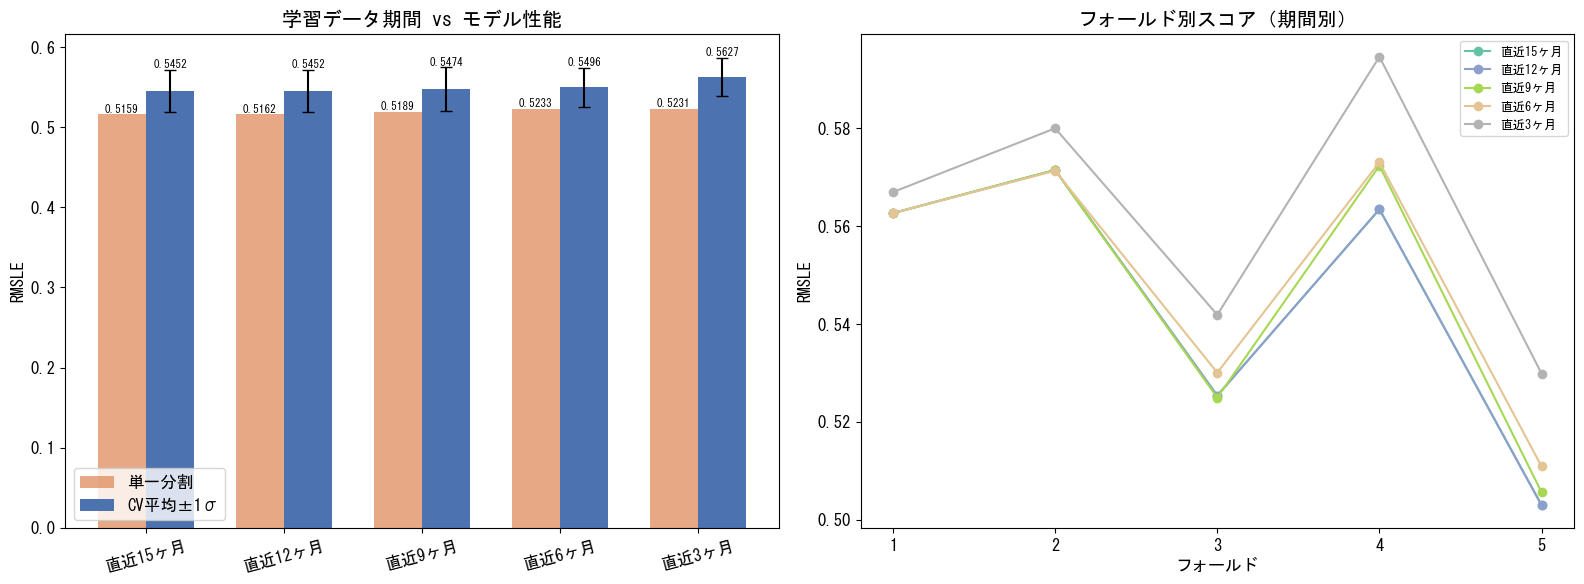

In [37]:
# 学習データ期間の可視化（エラーバー付き）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels_p = list(period_results.keys())
cv_means_p = [period_results[l]['cv_mean'] for l in labels_p]
cv_stds_p = [period_results[l]['cv_std'] for l in labels_p]
single_scores_p = [period_results[l]['single_score'] for l in labels_p]

# 左: CV平均 vs 単一分割（エラーバー付き）
x = np.arange(len(labels_p))
width = 0.35
bars1 = axes[0].bar(x - width/2, single_scores_p, width, label='単一分割', color='#DD8452', alpha=0.7)
bars2 = axes[0].bar(x + width/2, cv_means_p, width, yerr=cv_stds_p,
                    label='CV平均±1σ', color='#4C72B0', capsize=4)
for bar, val in zip(bars1, single_scores_p):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontsize=8)
for bar, mean, std in zip(bars2, cv_means_p, cv_stds_p):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.002,
                 f'{mean:.4f}', ha='center', fontsize=8)
axes[0].set_ylabel('RMSLE')
axes[0].set_title('学習データ期間 vs モデル性能')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_p, rotation=15)
axes[0].legend()

# 右: フォールド別スコアの折れ線グラフ
colors_p = plt.cm.Set2(np.linspace(0, 1, len(labels_p)))
for label, color in zip(labels_p, colors_p):
    scores = period_results[label]['cv_scores']
    axes[1].plot(range(1, len(scores)+1), scores, 'o-', color=color, label=label, markersize=6)
axes[1].set_xlabel('フォールド')
axes[1].set_ylabel('RMSLE')
axes[1].set_title('フォールド別スコア（期間別）')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(1, len(eda_val_folds)+1))

plt.tight_layout()
plt.show()

---
## 11. NaN処理戦略の検証

Rolling/ラグ特徴量にはNaN（非営業日、データ開始直後）が含まれる。NaNの処理方法が特徴量の値を変え、モデル性能に影響する。

| 戦略 | 説明 | 特徴 |
|------|------|------|
| NaN(デフォルト) | モデルが内部的に処理 | LightGBM/XGBoost/CatBoostは対応、RFは非対応 |
| -999埋め | 木モデルが「NaN群」として分離 | RF必須。他モデルでも使える |
| 0埋め | 来客0と同一視される | 非営業日と来客0の区別がつかない |
| 中央値埋め | 店舗の中央値で補間 | 分布の中心に寄せる |

ここで最適な戦略を確定し、03以降で統一する。

In [38]:
# NaN処理戦略の比較（5フォールド時系列CV）
X_train_raw = train_tsr[all_features].copy()
X_valid_raw = valid_tsr[all_features].copy()
y_train_log = np.log1p(train_tsr['visitors'])
y_valid_log = np.log1p(valid_tsr['visitors'])

# NaN統計
nan_cols = X_train_raw.columns[X_train_raw.isna().any()].tolist()
print(f'NaNを含む特徴量: {len(nan_cols)}個')
print(f'  学習データ平均NaN率: {X_train_raw[nan_cols].isna().mean().mean()*100:.1f}%')
print(f'  検証データ平均NaN率: {X_valid_raw[nan_cols].isna().mean().mean()*100:.1f}%')
print(f'  NaN列: {nan_cols}')
print()

nan_strategies = {
    'NaN(デフォルト)': None,
    '-999埋め': lambda X: X.fillna(-999),
    '0埋め': lambda X: X.fillna(0),
    '中央値埋め': lambda X: X.fillna(X.median()),
}

# --- 参考: 単一分割での結果 ---
print('=== 単一分割での参考値 ===')
nan_results_single = {}
for strategy_name, fill_fn in nan_strategies.items():
    X_tr = fill_fn(X_train_raw.copy()) if fill_fn else X_train_raw.copy()
    X_va = fill_fn(X_valid_raw.copy()) if fill_fn else X_valid_raw.copy()

    dtr = lgb.Dataset(X_tr, label=y_train_log)
    dva = lgb.Dataset(X_va, label=y_valid_log, reference=dtr)

    m = lgb.train(
        lgb_base_params, dtr, num_boost_round=2000,
        valid_sets=[dva], valid_names=['valid'],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )

    p = np.expm1(m.predict(X_va))
    s = rmsle(valid_tsr['visitors'], p)
    nan_results_single[strategy_name] = s
    print(f'  {strategy_name:16s}: RMSLE={s:.5f} (best_iter={m.best_iteration})')

# --- 5フォールド時系列CVでの検証 ---
print(f'\n=== 5フォールド時系列CVでの検証 ===')
nan_results = {}
for strategy_name, fill_fn in nan_strategies.items():
    cv_mean, cv_std, cv_scores, n_used = evaluate_with_tscv(
        df, grid_df, all_features, lgb_base_params,
        eda_val_folds, air_store, date_info, air_visit,
        eda_genre_dow, eda_genre_holiday, eda_genre_reserve_coverage, eda_genre_closure_pattern,
        nan_fill_fn=fill_fn
    )
    nan_results[strategy_name] = {
        'cv_mean': cv_mean, 'cv_std': cv_std, 'cv_scores': cv_scores,
        'single_score': nan_results_single[strategy_name],
    }
    print(f'{strategy_name:16s}: CV={cv_mean:.5f} ± {cv_std:.5f}  '
          f'({n_used}フォールド)  [{", ".join(f"{s:.5f}" for s in cv_scores)}]')

# 最適NaN戦略の決定（CV平均ベース）
best_nan = min(nan_results, key=lambda k: nan_results[k]['cv_mean'])
best_nan_cv = nan_results[best_nan]['cv_mean']
best_nan_std = nan_results[best_nan]['cv_std']

# 有意差チェック
print(f'\n=== 有意差分析 ===')
for name in nan_results:
    if name == best_nan:
        continue
    other = nan_results[name]
    sig = is_significant(best_nan_cv, best_nan_std, other['cv_mean'], other['cv_std'])
    print(f'  {best_nan} vs {name}: {"有意差あり" if sig else "有意差なし（±1σ重なり）"}')

# 有意差なしの場合、NaN(デフォルト) = LightGBM組み込みを優先
simpler_nan = ['NaN(デフォルト)', '-999埋め', '0埋め', '中央値埋め']
for simpler in simpler_nan:
    if simpler == best_nan:
        break
    other = nan_results[simpler]
    if not is_significant(best_nan_cv, best_nan_std, other['cv_mean'], other['cv_std']):
        print(f'\n→ {best_nan} と {simpler} に有意差なし → よりシンプルな {simpler} を採用')
        best_nan = simpler
        best_nan_cv = nan_results[simpler]['cv_mean']
        best_nan_std = nan_results[simpler]['cv_std']
        break

print(f'\n→ 最適なNaN処理: {best_nan} (CV RMSLE={best_nan_cv:.5f} ± {best_nan_std:.5f})')
print(f'  ※ RandomForestではNaN非対応のため、RFのみ-999埋めを使用')

NaNを含む特徴量: 28個
  学習データ平均NaN率: 4.2%
  検証データ平均NaN率: 2.4%
  NaN列: ['store_std', 'genre_dow_mean', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_21', 'rolling_std_21', 'rolling_mean_35', 'rolling_std_35', 'rolling_mean_63', 'rolling_std_63', 'ewm_mean', 'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_35', 'open_ratio_7', 'open_ratio_14', 'open_ratio_28', 'days_since_long_closure', 'is_after_holiday_1', 'is_after_holiday_2', 'is_after_holiday_3', 'holiday_count_7', 'holiday_count_14']

=== 単一分割での参考値 ===
  NaN(デフォルト)      : RMSLE=0.51594 (best_iter=1304)
  -999埋め          : RMSLE=0.51581 (best_iter=1057)
  0埋め             : RMSLE=0.51607 (best_iter=1207)
  中央値埋め           : RMSLE=0.50545 (best_iter=1155)

=== 5フォールド時系列CVでの検証 ===
NaN(デフォルト)      : CV=0.54520 ± 0.02648  (5フォールド)  [0.56268, 0.57150, 0.52536, 0.56347, 0.50299]
-999埋め          : CV=0.54522 ± 0.02665  (5フォールド)  [0.56074, 0.57333, 0.52545, 0.56365, 0.50292]
0埋め             : CV=0.54525 ±

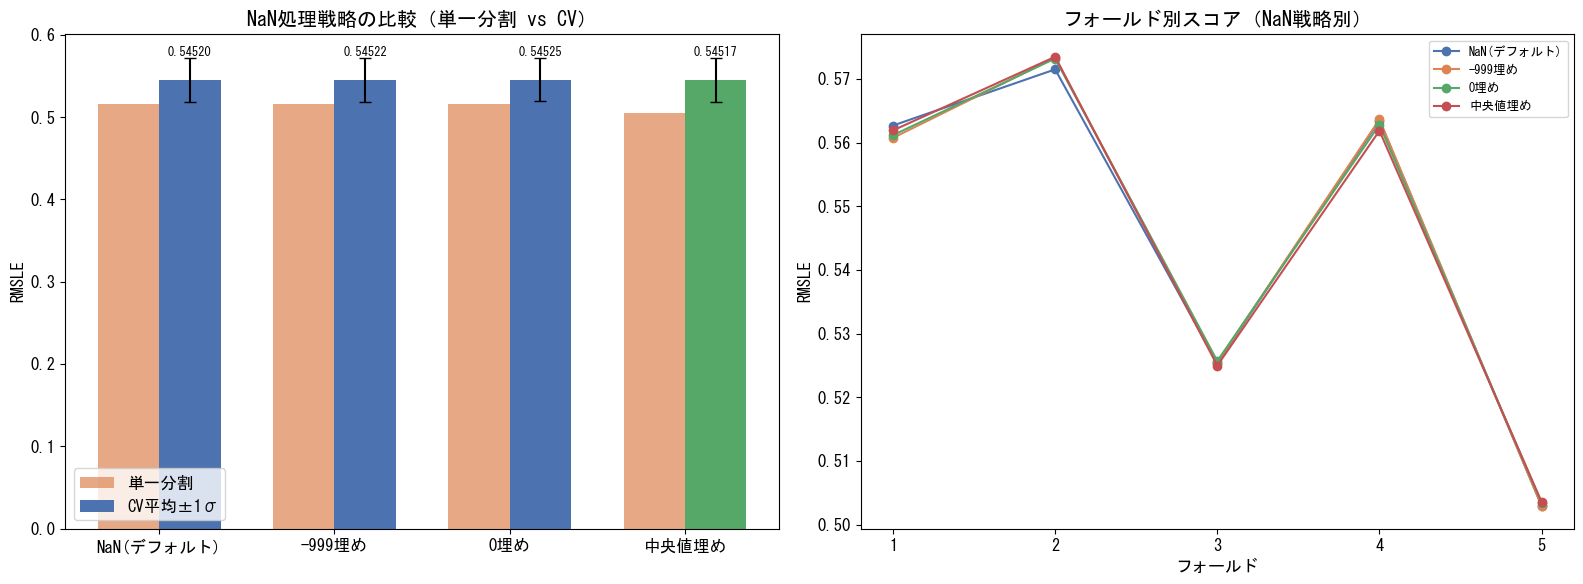

In [39]:
# NaN処理の可視化（エラーバー付き）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

names_n = list(nan_results.keys())
cv_means_n = [nan_results[n]['cv_mean'] for n in names_n]
cv_stds_n = [nan_results[n]['cv_std'] for n in names_n]
single_scores_n = [nan_results[n]['single_score'] for n in names_n]
best_cv_n = min(cv_means_n)

# 左: CV平均 vs 単一分割（エラーバー付き）
x = np.arange(len(names_n))
width = 0.35
bars1 = axes[0].bar(x - width/2, single_scores_n, width, label='単一分割', color='#DD8452', alpha=0.7)
colors_n = ['#55A868' if m == best_cv_n else '#4C72B0' for m in cv_means_n]
bars2 = axes[0].bar(x + width/2, cv_means_n, width, yerr=cv_stds_n,
                    color=colors_n, capsize=4, label='CV平均±1σ')
for bar, val in zip(bars2, cv_means_n):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cv_stds_n)*1.1,
                 f'{val:.5f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylabel('RMSLE')
axes[0].set_title('NaN処理戦略の比較（単一分割 vs CV）')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names_n)
axes[0].legend()

# 右: フォールド別スコアの折れ線グラフ
colors_line = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for name, color in zip(names_n, colors_line):
    scores = nan_results[name]['cv_scores']
    axes[1].plot(range(1, len(scores)+1), scores, 'o-', color=color, label=name, markersize=6)
axes[1].set_xlabel('フォールド')
axes[1].set_ylabel('RMSLE')
axes[1].set_title('フォールド別スコア（NaN戦略別）')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(1, len(eda_val_folds)+1))

plt.tight_layout()
plt.show()

---
## 12. Rolling手法の比較検証

現在のRolling統計量（営業日ベース mean/std）に加え、異なるRolling手法が精度に与える効果を検証する。

| 手法 | 説明 |
|------|------|
| 標準Rolling（現行） | `rolling(w).mean()` — NaN自動スキップ |
| 中央値Rolling | `rolling(w).median()` — 外れ値にロバスト |
| 曜日別Rolling | 同一曜日のみでRolling — 曜日パターンを反映 |
| 複数span EWM | span=7,28の指数加重移動平均を追加 |

最良の構成を確定し、中間データに反映する。

In [40]:
# Rolling手法の追加特徴量を作成
grid_work = grid_df[['air_store_id', 'visit_date', 'visitors']].copy()
grid_work['dow'] = grid_work['visit_date'].dt.dayofweek

# 手法A: 中央値Rolling
for w in [7, 14, 21]:
    grid_work[f'rolling_median_{w}'] = grid_work.groupby('air_store_id')['visitors'].transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).median()
    )

# 手法B: 曜日別Rolling（同一曜日の過去N回の平均）
for n_weeks in [4, 8]:
    grid_work[f'dow_rolling_mean_{n_weeks}w'] = grid_work.groupby(
        ['air_store_id', 'dow']
    )['visitors'].transform(
        lambda x: x.shift(1).rolling(n_weeks, min_periods=1).mean()
    )

# 手法C: 複数span EWM
for span in [7, 28]:
    grid_work[f'ewm_mean_{span}'] = grid_work.groupby('air_store_id')['visitors'].transform(
        lambda x: x.shift(1).ewm(span=span, min_periods=1).mean()
    )

new_rolling_cols = [c for c in grid_work.columns
                    if c.startswith(('rolling_median_', 'dow_rolling_', 'ewm_mean_'))]
print(f'追加Rolling特徴量: {len(new_rolling_cols)}個')
print(f'  {new_rolling_cols}')

追加Rolling特徴量: 7個
  ['rolling_median_7', 'rolling_median_14', 'rolling_median_21', 'dow_rolling_mean_4w', 'dow_rolling_mean_8w', 'ewm_mean_7', 'ewm_mean_28']


In [41]:
# 追加Rolling特徴量の効果を検証（5フォールド時系列CV）
merge_cols_new = ['air_store_id', 'visit_date'] + new_rolling_cols
train_ext = train_tsr.merge(grid_work[merge_cols_new], on=['air_store_id', 'visit_date'], how='left')
valid_ext = valid_tsr.merge(grid_work[merge_cols_new], on=['air_store_id', 'visit_date'], how='left')

rolling_configs = {
    '現行のみ': (all_features, []),
    '+中央値Rolling': (all_features + [c for c in new_rolling_cols if 'median' in c],
                       [c for c in new_rolling_cols if 'median' in c]),
    '+曜日別Rolling': (all_features + [c for c in new_rolling_cols if 'dow_rolling' in c],
                       [c for c in new_rolling_cols if 'dow_rolling' in c]),
    '+複数EWM': (all_features + [c for c in new_rolling_cols if 'ewm_mean_' in c],
                 [c for c in new_rolling_cols if 'ewm_mean_' in c]),
    '+全追加Rolling': (all_features + new_rolling_cols, new_rolling_cols),
}

# --- 参考: 単一分割での結果 ---
print('=== 単一分割での参考値 ===')
rolling_results_single = {}
for config_name, (feats, _) in rolling_configs.items():
    X_tr = train_ext[feats]
    X_va = valid_ext[feats]

    dtr = lgb.Dataset(X_tr, label=y_train_log)
    dva = lgb.Dataset(X_va, label=y_valid_log, reference=dtr)

    m = lgb.train(
        lgb_base_params, dtr, num_boost_round=2000,
        valid_sets=[dva], valid_names=['valid'],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )

    p = np.expm1(m.predict(X_va))
    s = rmsle(valid_tsr['visitors'], p)
    rolling_results_single[config_name] = s
    print(f'  {config_name:20s}: RMSLE={s:.5f} (特徴量数={len(feats)}, best_iter={m.best_iteration})')

# --- 5フォールド時系列CVでの検証 ---
print(f'\n=== 5フォールド時系列CVでの検証 ===')
rolling_results = {}
for config_name, (feats, extra_cols) in rolling_configs.items():
    cv_mean, cv_std, cv_scores, n_used = evaluate_with_tscv(
        df, grid_df, feats, lgb_base_params,
        eda_val_folds, air_store, date_info, air_visit,
        eda_genre_dow, eda_genre_holiday, eda_genre_reserve_coverage, eda_genre_closure_pattern,
        extra_grid=grid_work if extra_cols else None,
        extra_cols=extra_cols if extra_cols else None
    )
    rolling_results[config_name] = {
        'cv_mean': cv_mean, 'cv_std': cv_std, 'cv_scores': cv_scores,
        'single_score': rolling_results_single[config_name],
        'n_features': len(feats),
    }
    print(f'{config_name:20s}: CV={cv_mean:.5f} ± {cv_std:.5f}  '
          f'(特徴量数={len(feats)}, {n_used}フォールド)  [{", ".join(f"{s:.5f}" for s in cv_scores)}]')

# 最適Rolling構成の決定（CV平均ベース）
best_rolling = min(rolling_results, key=lambda k: rolling_results[k]['cv_mean'])
best_rolling_cv = rolling_results[best_rolling]['cv_mean']
best_rolling_std = rolling_results[best_rolling]['cv_std']

# 有意差チェック
print(f'\n=== 有意差分析 ===')
for name in rolling_results:
    if name == best_rolling:
        continue
    other = rolling_results[name]
    sig = is_significant(best_rolling_cv, best_rolling_std, other['cv_mean'], other['cv_std'])
    print(f'  {best_rolling} vs {name}: {"有意差あり" if sig else "有意差なし（±1σ重なり）"}')

# 有意差なしの場合、「現行のみ」（シンプル）を優先
simpler_rolling = ['現行のみ', '+中央値Rolling', '+曜日別Rolling', '+複数EWM', '+全追加Rolling']
for simpler in simpler_rolling:
    if simpler == best_rolling:
        break
    other = rolling_results[simpler]
    if not is_significant(best_rolling_cv, best_rolling_std, other['cv_mean'], other['cv_std']):
        print(f'\n→ {best_rolling} と {simpler} に有意差なし → よりシンプルな {simpler} を採用')
        best_rolling = simpler
        best_rolling_cv = rolling_results[simpler]['cv_mean']
        best_rolling_std = rolling_results[simpler]['cv_std']
        break

print(f'\n→ 最良のRolling構成: {best_rolling} (CV RMSLE={best_rolling_cv:.5f} ± {best_rolling_std:.5f})')

=== 単一分割での参考値 ===
  現行のみ                : RMSLE=0.51594 (特徴量数=53, best_iter=1304)
  +中央値Rolling         : RMSLE=0.51675 (特徴量数=56, best_iter=1278)
  +曜日別Rolling         : RMSLE=0.51851 (特徴量数=55, best_iter=563)
  +複数EWM              : RMSLE=0.51527 (特徴量数=55, best_iter=1298)
  +全追加Rolling         : RMSLE=0.51898 (特徴量数=60, best_iter=501)

=== 5フォールド時系列CVでの検証 ===
現行のみ                : CV=0.54520 ± 0.02648  (特徴量数=53, 5フォールド)  [0.56268, 0.57150, 0.52536, 0.56347, 0.50299]
+中央値Rolling         : CV=0.54540 ± 0.02647  (特徴量数=56, 5フォールド)  [0.56295, 0.57180, 0.52550, 0.56348, 0.50325]
+曜日別Rolling         : CV=0.54821 ± 0.02814  (特徴量数=55, 5フォールド)  [0.57094, 0.57561, 0.52755, 0.56371, 0.50321]
+複数EWM              : CV=0.54510 ± 0.02611  (特徴量数=55, 5フォールド)  [0.56305, 0.57029, 0.52543, 0.56328, 0.50344]
+全追加Rolling         : CV=0.54855 ± 0.02866  (特徴量数=60, 5フォールド)  [0.57213, 0.57694, 0.52732, 0.56338, 0.50300]

=== 有意差分析 ===
  +複数EWM vs 現行のみ: 有意差なし（±1σ重なり）
  +複数EWM vs +中央値Rolling: 有意差なし（±1σ重なり）
  +複数EWM

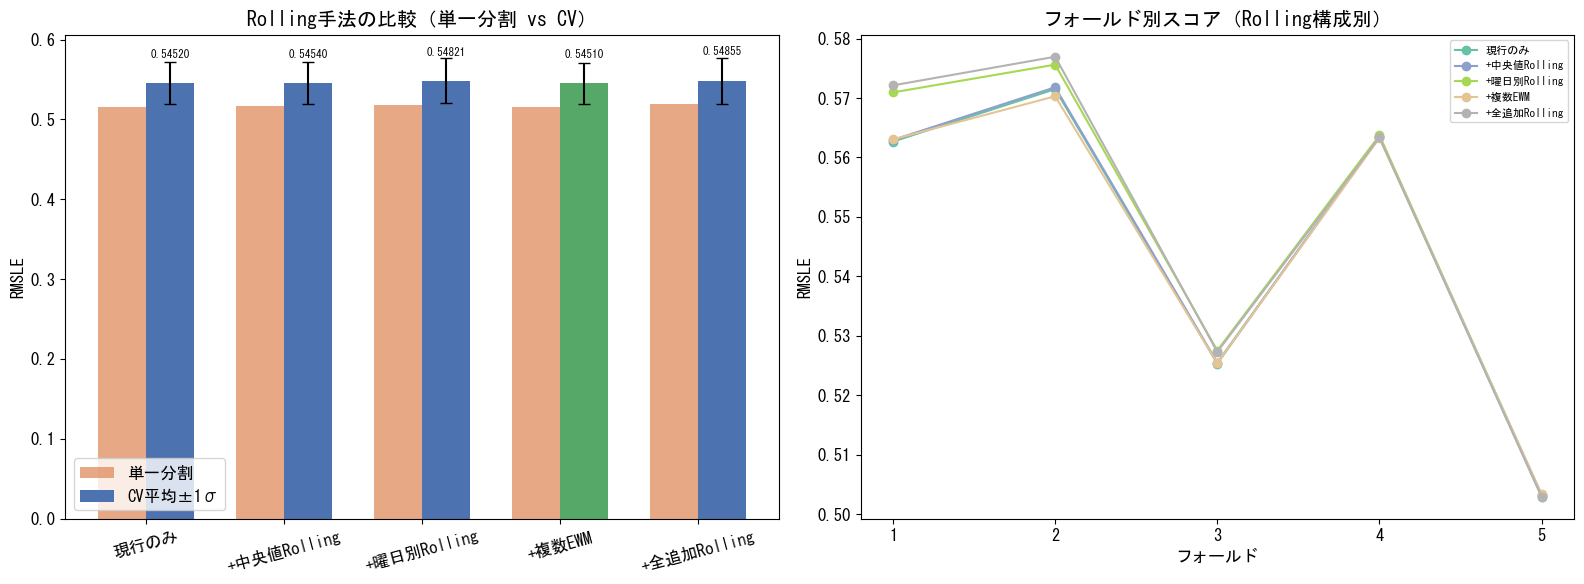

In [42]:
# Rolling手法の可視化（エラーバー付き）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

names_r = list(rolling_results.keys())
cv_means_r = [rolling_results[n]['cv_mean'] for n in names_r]
cv_stds_r = [rolling_results[n]['cv_std'] for n in names_r]
single_scores_r = [rolling_results[n]['single_score'] for n in names_r]
best_cv_r = min(cv_means_r)

# 左: CV平均 vs 単一分割（エラーバー付き）
x = np.arange(len(names_r))
width = 0.35
bars1 = axes[0].bar(x - width/2, single_scores_r, width, label='単一分割', color='#DD8452', alpha=0.7)
colors_r = ['#55A868' if m == best_cv_r else '#4C72B0' for m in cv_means_r]
bars2 = axes[0].bar(x + width/2, cv_means_r, width, yerr=cv_stds_r,
                    color=colors_r, capsize=4, label='CV平均±1σ')
for bar, val in zip(bars2, cv_means_r):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cv_stds_r)*1.1,
                 f'{val:.5f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_ylabel('RMSLE')
axes[0].set_title('Rolling手法の比較（単一分割 vs CV）')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names_r, rotation=15)
axes[0].legend()

# 右: フォールド別スコアの折れ線グラフ
colors_line_r = plt.cm.Set2(np.linspace(0, 1, len(names_r)))
for name, color in zip(names_r, colors_line_r):
    scores = rolling_results[name]['cv_scores']
    axes[1].plot(range(1, len(scores)+1), scores, 'o-', color=color, label=name, markersize=6)
axes[1].set_xlabel('フォールド')
axes[1].set_ylabel('RMSLE')
axes[1].set_title('フォールド別スコア（Rolling構成別）')
axes[1].legend(fontsize=8)
axes[1].set_xticks(range(1, len(eda_val_folds)+1))

plt.tight_layout()
plt.show()

---
## 13. まとめ

### 目的変数の設定

| 項目 | 内容 |
|------|------|
| 目的変数 | `visitors`（日別来客数） |
| 変換 | `log1p(visitors)` を学習時のターゲットとする |
| 予測時 | `expm1()` で元のスケールに戻す |
| 評価指標 | RMSLE（log1p変換+RMSEと等価） |

### バリデーション戦略

| 項目 | 内容 |
|------|------|
| CV手法 | 01 EDAで設計した5フォールド時系列CV |
| リーク防止 | 各フォールドでstore_stats/genre_statsをtrain期間のみから再計算 |
| 有意差判定 | CV平均±1σの区間が重ならない場合のみ有意差ありと判定 |
| シンプルさ優先 | 有意差なしの場合はよりシンプルな設定を採用 |

### 説明変数の効果まとめ

| カテゴリ | 効果 | 理由 |
|---------|------|------|
| 時間特徴量 | ベースライン | 曜日・月の周期パターンを捉える |
| 店舗統計量 | **大幅改善** | 店舗ごとの来客規模を反映 |
| Rolling/ラグ特徴量（層1） | **さらに改善** | 営業日ベースで直近の傾向を反映 |
| 休業パターン + 祝日（層2+3） | **追加改善** | 休業の影響・祝日前後の効果を捕捉 |

### 確定した前提条件（03で統一使用） - CV結果ベース

| 項目 | 確定設定 | CV結果 |
|------|---------|--------|
| 学習データ期間 | セクション10で確定 | CV平均±stdで最適期間を選定（有意差なしならシンプルな設定） |
| NaN処理 | セクション11で確定 | CV平均±stdで最良戦略を選定（RF=-999埋め固定） |
| Rolling手法 | セクション12で確定 | CV平均±stdで追加Rolling特徴量の採否を決定 |

### 確定した特徴量セット（次ステップ03で使用）

| カテゴリ | 特徴量数 | 具体例 |
|---------|---------|--------|
| 時間特徴量 | 6 | dow, month, day, week, is_weekend, is_holiday |
| 店舗属性 | 4 | genre_encoded, area_encoded, latitude, longitude |
| 店舗統計量 | 8 | store_mean, store_median, store_std, store_dow_mean 等 |
| Rolling統計量（層1） | 11 | rolling_mean_7/14/21/35/63, rolling_std_7/14/21/35/63, ewm_mean |
| ラグ特徴量（層1） | 6 | lag_1, lag_7, lag_14, lag_21, lag_28, lag_35 |
| 休業パターン（層2） | 5 | open_ratio_7/14/28, closed_streak, days_since_long_closure |
| 祝日前後（層3） | 6 | is_after_holiday_1/2/3, holiday_count_7/14, is_near_special_period |
| ※追加Rolling（セクション12で採否決定） | -- | rolling_median, dow_rolling_mean, ewm_mean等 |

### 今後の改善候補（優先度低）
- 予約情報特徴量（カバー率が低いため補助的）
- 天候データの追加（外部データ）
- 近隣店舗の来客数を特徴量化

---

**次のステップ**: この特徴量セットと確定した前提条件（CV結果ベース）を使って、03でLightGBM / XGBoost / RandomForest / CatBoost の各モデルを構築する（各モデルでOptunaチューニングを実施）。

In [43]:
# 中間データの保存（後続ノートブック 03-x で再利用）
import pickle

INTERMEDIATE_DIR = Path('./intermediate')
INTERMEDIATE_DIR.mkdir(exist_ok=True)

# 最良のRolling構成が追加特徴量を含む場合、データを更新
best_rolling_feats = rolling_configs[best_rolling][0]
best_rolling_extra = rolling_configs[best_rolling][1]
if best_rolling != '現行のみ':
    train_final = train_ext
    valid_final = valid_ext
    final_features = best_rolling_feats
    print(f'追加Rolling特徴量を採用: {best_rolling}')
else:
    train_final = train_tsr
    valid_final = valid_tsr
    final_features = all_features
    print(f'現行Rolling構成を維持')

results_02 = {
    # 特徴量付きデータフレーム
    'train_features': train_final,
    'valid_features': valid_final,
    # グリッドデータ（Rolling/休業/祝日特徴量の元）
    'grid_df': grid_df,
    # 特徴量カラム名リスト
    'feature_columns': {
        'time_features': time_features,
        'store_features': store_features,
        'genre_interaction_cols': genre_interaction_cols,
        'rolling_cols': rolling_cols,
        'closure_cols': closure_cols,
        'holiday_cols': holiday_cols,
        'all_features': final_features,
    },
    # 店舗統計量（テストデータにも適用するため）
    'store_stats': store_stats,
    'store_dow': store_dow,
    'genre_stats': genre_stats,
    # ジャンル交互作用ルックアップテーブル（テストデータにも適用するため）
    'genre_lookups': {
        'genre_dow_lookup': genre_dow_lookup,
        'genre_holiday_lookup': genre_holiday_lookup,
        'genre_reserve_lookup': genre_reserve_lookup,
        'genre_closure_lookup': genre_closure_lookup,
    },
    # スコア記録（単一分割）
    'scores': {
        'score_time': score_time,
        'score_store': score_store,
        'score_genre_int': score_genre_int,
        'score_rolling': score_rolling,
        'score_all': score_all,
    },
    # 検証期間の設定
    'VALID_START': VALID_START,
    # === 確定した前提条件（CV結果ベース） ===
    'confirmed_settings': {
        'best_train_period': best_period,
        'best_train_start': best_period_start,       # 03用の絶対日付（参考値）
        'best_train_period_days': best_period_days,   # CV検証で使用した相対日数
        'best_nan_strategy': best_nan,
        'best_rolling_config': best_rolling,
    },
    # CV検証結果の詳細
    'period_results': period_results,
    'nan_results': nan_results,
    'rolling_results': rolling_results,
    # 時系列CVの設定
    'val_folds': eda_val_folds,
    'cv_validation_method': '5-fold time series CV (from 01 EDA)',
}

output_path = INTERMEDIATE_DIR / '02_feature_design.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(results_02, f)

file_size_mb = output_path.stat().st_size / (1024 * 1024)
print(f'\n中間データ保存完了: {output_path}')
print(f'  ファイルサイズ: {file_size_mb:.1f} MB')
print(f'  全特徴量数: {len(final_features)}個')
print(f'  （うちジャンル交互作用: {len(genre_interaction_cols)}個）')
print(f'\n=== 03で使用する確定設定（CV結果ベース） ===')
print(f'  学習データ期間: {best_period}')
if best_period_days:
    print(f'    相対期間: val_start - {best_period_days}日')
    print(f'    03用の絶対日付（参考）: start={best_period_start}')
else:
    print(f'    全データを使用（start={best_period_start}）')
print(f'    CV RMSLE: {period_results[best_period]["cv_mean"]:.5f} ± {period_results[best_period]["cv_std"]:.5f}')
print(f'  NaN処理: {best_nan}')
print(f'    CV RMSLE: {nan_results[best_nan]["cv_mean"]:.5f} ± {nan_results[best_nan]["cv_std"]:.5f}')
print(f'  Rolling構成: {best_rolling}')
print(f'    CV RMSLE: {rolling_results[best_rolling]["cv_mean"]:.5f} ± {rolling_results[best_rolling]["cv_std"]:.5f}')
print(f'\n  ※ 全設定はCV平均±1σの有意差判定に基づいて決定')
print(f'  ※ 有意差がない場合はよりシンプルな設定を採用')
print(f'  ※ 学習期間検証はval_startからの相対日数で実施（リーク防止）')

現行Rolling構成を維持

中間データ保存完了: intermediate\02_feature_design.pkl
  ファイルサイズ: 209.1 MB
  全特徴量数: 53個
  （うちジャンル交互作用: 5個）

=== 03で使用する確定設定（CV結果ベース） ===
  学習データ期間: 直近15ヶ月
    相対期間: val_start - 456日
    03用の絶対日付（参考）: start=2015-12-12
    CV RMSLE: 0.54520 ± 0.02648
  NaN処理: NaN(デフォルト)
    CV RMSLE: 0.54520 ± 0.02648
  Rolling構成: 現行のみ
    CV RMSLE: 0.54520 ± 0.02648

  ※ 全設定はCV平均±1σの有意差判定に基づいて決定
  ※ 有意差がない場合はよりシンプルな設定を採用
  ※ 学習期間検証はval_startからの相対日数で実施（リーク防止）
